# Chapter 5: Linear Models and Regularization

*Reproduction + theoretical summary of Chapter 5 of **scikit-learn Cookbook, Third Edition** (John Sukup, O'Reilly/Packt).*

Linear regression is probably the first model most of us meet at school: find the line that best describes a relationship. This chapter starts there (**Ordinary Least Squares, OLS**) and then asks what goes wrong when a line has *too much freedom* (many features, correlated features, few samples) and how a **penalty on the size of the coefficients**, called *regularization*, repairs it.

The book has five recipes plus three exercises. This notebook follows the same order:

| # | Recipe | Main tools |
|---|--------|-----------|
| 1 | Introduction to linear models | `LinearRegression`, MSE, $R^2$ |
| 2 | Ridge and Lasso regression | `Ridge` (L2), `Lasso` (L1), `alpha` |
| 3 | ElasticNet and regularization | `ElasticNet`, `l1_ratio`, coefficient paths |
| 4 | Regularization theory and practice | complexity, bias-variance, choosing `alpha` |
| 5 | Regression and regularization | `PolynomialFeatures`, `SplineTransformer` |
| 6 | Practical exercises | Ridge, Lasso and ElasticNet on one problem |

As in earlier chapters, each recipe has (1) theory, (2) the book's code reproduced, and (3) extra experiments that put numbers behind the book's statements. Where the book is imprecise, a **📝 Note** explains. This chapter has more of them than usual, because the book's main dataset turns out to have a flaw that changes how its results should be read (Section 1.2).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.datasets import make_regression
from sklearn.model_selection import (train_test_split, cross_val_score, cross_validate,
                                     RepeatedKFold, KFold, validation_curve)
from sklearn.linear_model import (LinearRegression, Ridge, Lasso, ElasticNet, RidgeCV, LassoCV,
                                  ElasticNetCV, BayesianRidge, lasso_path, enet_path)
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, SplineTransformer
from sklearn.pipeline import make_pipeline, Pipeline

np.random.seed(123)                      # the book asks for 123 wherever reproducibility matters
pd.set_option("display.precision", 4)
pd.set_option("display.width", 150)

print("scikit-learn:", sklearn.__version__)
print("NumPy       :", np.__version__)
print("pandas      :", pd.__version__)

scikit-learn: 1.9.1
NumPy       : 2.5.3
pandas      : 3.0.6


## 1. Introduction to linear models

### 1.1 Theory

A linear model says that the target is a weighted sum of the features plus an error:

$$y=\beta_0+\beta_1x_1+\beta_2x_2+\dots+\beta_px_p+\varepsilon=\mathbf x^{\top}\boldsymbol\beta+\varepsilon .$$

* $\beta_0$ is the **intercept** (`intercept_`), $\beta_j$ the **coefficient** of feature $j$ (`coef_`): the expected change in $y$ when $x_j$ grows by one unit and the other features stay fixed.
* $\varepsilon$ is the error term: whatever the features cannot explain.

**Ordinary Least Squares** picks the coefficients that minimise the sum of squared residuals (the *residual sum of squares*, RSS):

$$\hat{\boldsymbol\beta}=\arg\min_{\boldsymbol\beta}\ \sum_{i=1}^{n}\bigl(y_i-\mathbf x_i^{\top}\boldsymbol\beta\bigr)^2
\quad\Longrightarrow\quad
\hat{\boldsymbol\beta}=(\mathbf X^{\top}\mathbf X)^{-1}\mathbf X^{\top}\mathbf y\ \ \text{(the normal equations; $\mathbf X$ includes a column of ones)}.$$

**Classical assumptions** behind the good properties of OLS: the relationship is linear in the coefficients; errors have zero mean and constant variance; errors are independent; the features are not perfectly collinear (otherwise $\mathbf X^{\top}\mathbf X$ cannot be inverted). OLS has **no tuning knob**: it always chases the lowest *training* error, which is exactly why it can over-fit when there are many features or they are strongly correlated. That is the problem regularization solves.

**Metrics** used throughout the chapter (computed on held-out data):

$$\text{MSE}=\frac1n\sum_i(y_i-\hat y_i)^2,\qquad \text{RMSE}=\sqrt{\text{MSE}},\qquad R^2=1-\frac{\sum_i(y_i-\hat y_i)^2}{\sum_i(y_i-\bar y)^2}.$$

MSE is in *squared target units* (hard to read), RMSE is in target units, and $R^2$ compares the model with the trivial predictor "always predict the mean" ($R^2=0$ means no better than the mean, and it can be **negative** on new data).

### 1.1b A first check: the normal equations really are what scikit-learn computes

In [2]:
rng = np.random.RandomState(0)
n, p = 200, 5
X_small = rng.normal(size=(n, p))
beta_true = np.array([3.0, -2.0, 0.0, 0.0, 1.5])
y_small = X_small @ beta_true + 4.0 + rng.normal(0, 1, n)

X_aug = np.hstack([np.ones((n, 1)), X_small])                       # column of ones for the intercept
beta_hat = np.linalg.solve(X_aug.T @ X_aug, X_aug.T @ y_small)      # normal equations

sk = LinearRegression().fit(X_small, y_small)
print("true coefficients     :", beta_true, "| true intercept 4.0")
print("normal equations      :", beta_hat[1:].round(4), "| intercept", beta_hat[0].round(4))
print("LinearRegression      :", sk.coef_.round(4), "| intercept", sk.intercept_.round(4))
print("identical             :", np.allclose(beta_hat[1:], sk.coef_) and np.allclose(beta_hat[0], sk.intercept_))

true coefficients     : [ 3.  -2.   0.   0.   1.5] | true intercept 4.0
normal equations      : [ 2.9610e+00 -2.1446e+00 -3.0000e-04 -3.3400e-02  1.5130e+00] | intercept 4.0799
LinearRegression      : [ 2.9610e+00 -2.1446e+00 -3.0000e-04 -3.3400e-02  1.5130e+00] | intercept 4.0799
identical             : True


### 1.2 The book's synthetic dataset

To show how regularization behaves, the book builds a dataset with **1 000 samples and 100 features**, of which 10 are informative, then makes half of the features **correlated** copies of the other half, scales the target and adds a "non-linear" term. We reproduce the recipe step by step.

Two deviations from the book's code, both harmless: (1) `coef=True` is added to `make_regression` so that we can see the true coefficients (the returned `X` and `y` are identical with or without it), and (2) the book does not seed the noise it adds to the correlated columns, so its numbers change on every run. Here `np.random.seed(123)` makes the notebook reproducible, and our numbers can differ slightly from the book's figures.

In [3]:
X, y, true_coef = make_regression(n_samples=1000, n_features=100, n_informative=10,
                                  noise=20, random_state=123, coef=True)
X_original = X.copy()                      # kept only for the diagnosis below

# Add multicollinearity: make half of the features correlated (copy of column i-50 plus a bit of noise)
np.random.seed(123)
for i in range(50, 100):
    X[:, i] = X[:, i - 50] + np.random.normal(0, 0.1, size=1000)

feature_names = [f"feature_{i}" for i in range(100)]
X_plot = X[:, 0].reshape(-1, 1)            # first feature, for 2-D plots

# Scale the target and add 'non-linearity' (exactly as in the book)
y = y * 1000
y = y + np.sin(X_plot.ravel()) * 150 + np.exp(X_plot.ravel() / 10)

df = pd.DataFrame(X, columns=feature_names)
df["target"] = y
print("shape:", df.shape, "| target mean = %.0f, std = %.0f" % (y.mean(), y.std()))
print("correlation of feature_0 with its copy feature_50: %.4f" % np.corrcoef(X[:, 0], X[:, 50])[0, 1])

shape: (1000, 101) | target mean = 1229, std = 223821
correlation of feature_0 with its copy feature_50: 0.9952


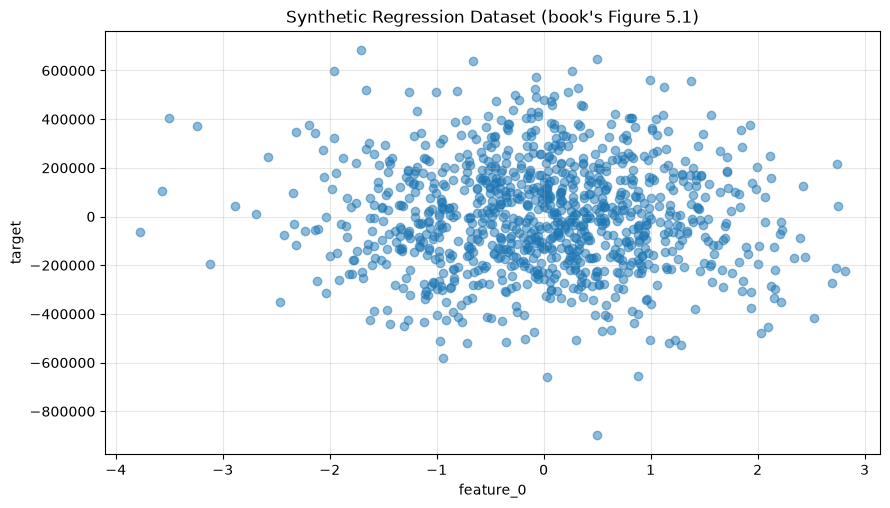

In [4]:
plt.figure(figsize=(10, 5.5))
plt.scatter(X_plot, y, alpha=0.5)
plt.xlabel("feature_0"); plt.ylabel("target"); plt.title("Synthetic Regression Dataset (book's Figure 5.1)")
plt.grid(alpha=0.3); plt.show()

The cloud looks random: with 100 features, a single one explains little. Before fitting anything, let us check something the book never does: **what signal is actually left in this dataset?**

### 1.2b Diagnosis: the recipe destroys most of its own signal

In [5]:
informative = np.where(true_coef != 0)[0]
kept = [int(j) for j in informative if j < 50]          # columns 0-49 are NOT overwritten
lost = [int(j) for j in informative if j >= 50]         # columns 50-99 ARE overwritten by the loop

signal_total = np.var(X_original @ true_coef)
signal_lost = np.var(X_original[:, lost] @ true_coef[lost])
signal_kept = np.var(X_original[:, kept] @ true_coef[kept])
added_term = np.sin(X_plot.ravel()) * 150 + np.exp(X_plot.ravel() / 10)

print("informative columns             :", informative.tolist())
print("  intact (index < 50)           :", kept)
print("  OVERWRITTEN by the loop (>=50):", lost)
print(f"share of the signal variance that was destroyed : {signal_lost / signal_total:.1%}")
print(f"highest R^2 any linear model could reach        : about {signal_kept * 1000**2 / y.var():.2f}")
print(f"size of the added sin/exp term vs std of target : {added_term.std():.0f} vs {y.std():.0f}  ({added_term.std() / y.std():.3%})")

informative columns             : [3, 21, 25, 66, 68, 71, 75, 81, 98, 99]
  intact (index < 50)           : [3, 21, 25]
  OVERWRITTEN by the loop (>=50): [66, 68, 71, 75, 81, 98, 99]
share of the signal variance that was destroyed : 76.8%
highest R^2 any linear model could reach        : about 0.23
size of the added sin/exp term vs std of target : 98 vs 223821  (0.044%)


**What the diagnosis shows.** The correlated-features loop writes `X[:, i] = X[:, i-50] + noise` into columns 50-99. But `make_regression` had placed **7 of its 10 informative features in exactly those columns** (66, 68, 71, 75, 81, 98, 99), and `y` had already been computed from their *original* values. After the overwrite, the part of `y` that came from those 7 features is no longer related to any column of `X`: for a model it is just extra noise.

* **76.8 % of the signal variance is destroyed**, so even a perfect linear model could reach an $R^2$ of only **about 0.23** on this data. This is why Figure 5.1 looks like a shapeless cloud, and why *every* $R^2$ in the recipe (the book's 0.09-0.14) should be compared with **0.23, not with 1.0**.
* The "non-linearity" the book adds ($\sin$ and $\exp$ terms) has a standard deviation of about 98 against 223 821 for the target (0.04 %): it is numerically invisible.
* The book's explanation, "the difference is small because the data is highly multicollinear", is therefore only part of the story. The larger reasons are the low ceiling of 0.23 and (Section 2.4) the choice of `alpha`.

We keep the book's dataset for Sections 1-3 so that the recipe's numbers can be reproduced, but we build a **corrected dataset** in Section 2.7 where the benefits of regularization are visible.

### 1.3 Fitting `LinearRegression` (the book's recipe)

As in earlier chapters: split first (80 / 20, `random_state=123`), fit on the training part, evaluate on the held-out part.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred = linear_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")
print()
print(f"RMSE                 : {np.sqrt(mse):,.0f}   (std of the test target: {y_test.std():,.0f})")
print(f"R^2 on training data : {linear_model.score(X_train, y_train):.3f}")
print(f"R^2 on test data     : {r2:.3f}")

Mean Squared Error: 46550591070.53
R-squared: 0.06

RMSE                 : 215,756   (std of the test target: 223,102)
R^2 on training data : 0.323
R^2 on test data     : 0.065


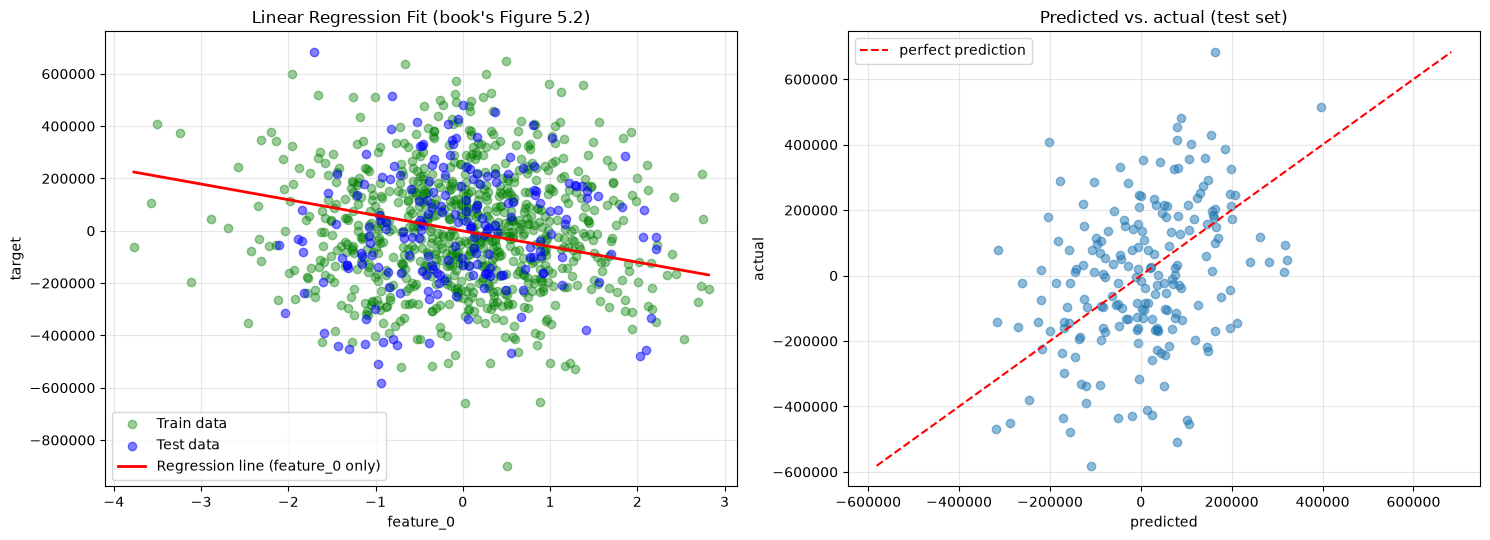

slope of the red line (coef of feature_0)     : -59720
slope along the data (feature_0 + its copy)    : -8969


In [7]:
# The book's Figure 5.2: the fitted line against feature_0 (all other features held at 0)
X_line = np.linspace(df["feature_0"].min(), df["feature_0"].max(), 100).reshape(-1, 1)
X_line_full = np.zeros((100, len(feature_names)))
X_line_full[:, 0] = X_line.ravel()
y_line = linear_model.predict(X_line_full)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
ax = axes[0]
ax.scatter(X_train[:, 0], y_train, color="green", alpha=0.4, label="Train data")
ax.scatter(X_test[:, 0], y_test, color="blue", alpha=0.5, label="Test data")
ax.plot(X_line, y_line, color="red", lw=2, label="Regression line (feature_0 only)")
ax.set_xlabel("feature_0"); ax.set_ylabel("target"); ax.set_title("Linear Regression Fit (book's Figure 5.2)"); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]                                                   # extra: predicted vs. actual
lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.scatter(y_pred, y_test, alpha=0.5); ax.plot(lim, lim, "r--", label="perfect prediction")
ax.set_xlabel("predicted"); ax.set_ylabel("actual"); ax.set_title("Predicted vs. actual (test set)"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("slope of the red line (coef of feature_0)     :", round(linear_model.coef_[0]))
print("slope along the data (feature_0 + its copy)    :", round(linear_model.coef_[0] + linear_model.coef_[50]))

**Reading the result.**

* Test $R^2$ is **0.06** (the book's figure for its own, unseeded run is 0.09). The RMSE of 215 756 is hardly smaller than the standard deviation of the target (223 102): the predictions are barely better than the mean.
* Training $R^2$ is **0.32**, *above* the 0.23 ceiling computed in Section 1.2b. A model cannot honestly explain more than the signal available, so the surplus is **noise memorised by 100 coefficients fitted to 800 rows**: the textbook sign of over-fitting.
* **The red "regression line" in the book's Figure 5.2 is not the trend of the data.** To draw it against one axis, the book sets the other 99 features to 0, so the line shows the model's response along `feature_0` alone. Its slope is the coefficient of `feature_0`, here about -59 720, even though `feature_0` has a true coefficient of **zero**. Adding its near-twin `feature_50` gives a combined slope of only about -8 969: two huge coefficients that largely cancel. That is the signature of multicollinearity (Section 1.4), and the reason to distrust individual OLS coefficients here.

### 1.4 How it works, and where it breaks

OLS is a perfectly good model when there are **many more samples than features** and the features are **not strongly correlated**. Two situations push it into trouble, and both are present in this chapter's datasets:

1. **Too many features for the amount of data** → the fit memorises noise (high training $R^2$, poor test $R^2$).
2. **Correlated features** → $\mathbf X^{\top}\mathbf X$ is nearly singular, so the coefficients become huge and unstable: the data can say "the sum of the two weights is 6" but not "how it is split between them". We will measure this in Section 3.5.

The remedies the book names in "There's more": **regularized regression** (Ridge, Lasso, ElasticNet) and, for classification, **logistic regression** (Chapter 6).

## 2. Ridge and Lasso regression

### 2.1 Theory: a penalty on the size of the coefficients

Regularization changes the objective from "fit the training data as closely as possible" to "fit it well **and** keep the coefficients small":

$$\underbrace{\text{RSS}(\boldsymbol\beta)}_{\text{fit}}\;+\;\underbrace{\alpha\cdot\text{penalty}(\boldsymbol\beta)}_{\text{complexity cost}} .$$

`alpha` ($\alpha\ge 0$) sets the price: $\alpha=0$ gives back OLS, a huge $\alpha$ pushes all coefficients to 0 (a model that only predicts the mean). The **intercept is never penalised**.

| Model | Penalty | scikit-learn objective (what the code really minimises) |
|-------|---------|----------------------------------------------|
| **Ridge** (L2) | $\sum_j\beta_j^2$ | $\ \lVert\mathbf y-\mathbf X\boldsymbol\beta\rVert_2^2+\alpha\lVert\boldsymbol\beta\rVert_2^2$ |
| **Lasso** (L1) | $\sum_j\lvert\beta_j\rvert$ | $\ \dfrac1{2n}\lVert\mathbf y-\mathbf X\boldsymbol\beta\rVert_2^2+\alpha\lVert\boldsymbol\beta\rVert_1$ |

> **📝 Note: the two `alpha`s are not on the same scale.** The book writes both losses as "sum of squared errors + $\alpha\cdot$penalty" and then uses `Ridge(alpha=1)` next to `Lasso(alpha=10)` as if they were comparable. In scikit-learn, **Ridge** uses exactly that form, but **Lasso** (and ElasticNet) *divide the error term by $2n$*. Consequently an $\alpha$ of 1 is a *weak* penalty for Ridge on 800 samples but a much *stronger* one for Lasso, and the same number must never be compared across the two classes. We verify the exact forms numerically in Section 2.2.

**Why the two behave so differently: closed forms.**

* **Ridge** has a closed-form solution, $\hat{\boldsymbol\beta}_{\text{ridge}}=(\mathbf X^{\top}\mathbf X+\alpha\mathbf I)^{-1}\mathbf X^{\top}\mathbf y$ (on centred data). Adding $\alpha\mathbf I$ makes the matrix invertible even when features are collinear. Every coefficient is shrunk *proportionally*, but none becomes exactly zero.
* **Lasso** has no closed form in general, but in the simple case of **orthonormal features** ($\mathbf X^{\top}\mathbf X=n\mathbf I$) it reduces to the **soft-threshold** of the OLS coefficients,
$$\hat\beta^{\text{lasso}}_j=\operatorname{sign}(\hat\beta^{\text{ols}}_j)\,\max\bigl(\lvert\hat\beta^{\text{ols}}_j\rvert-\alpha,\;0\bigr),\qquad\text{while}\qquad
\hat\beta^{\text{ridge}}_j=\frac{\hat\beta^{\text{ols}}_j}{1+\alpha/n}\ \ \text{(Ridge with its own $\alpha$)} .$$
  Lasso subtracts a **fixed amount** from every coefficient and clips at zero: small coefficients are eliminated entirely, so Lasso performs **feature selection**. Ridge multiplies by a factor below 1: it *shrinks* but never eliminates.

**The geometry.** Both problems can be seen as "minimise the RSS **inside a budget region** for the coefficients". The RSS contours are ellipses around the OLS solution; the region is a **disc** for Ridge and a **diamond** for Lasso. The best point is where the first contour touches the region. The diamond has *corners on the axes*, so contacts there are likely, and a corner means one coefficient is exactly 0. The disc has no corners.

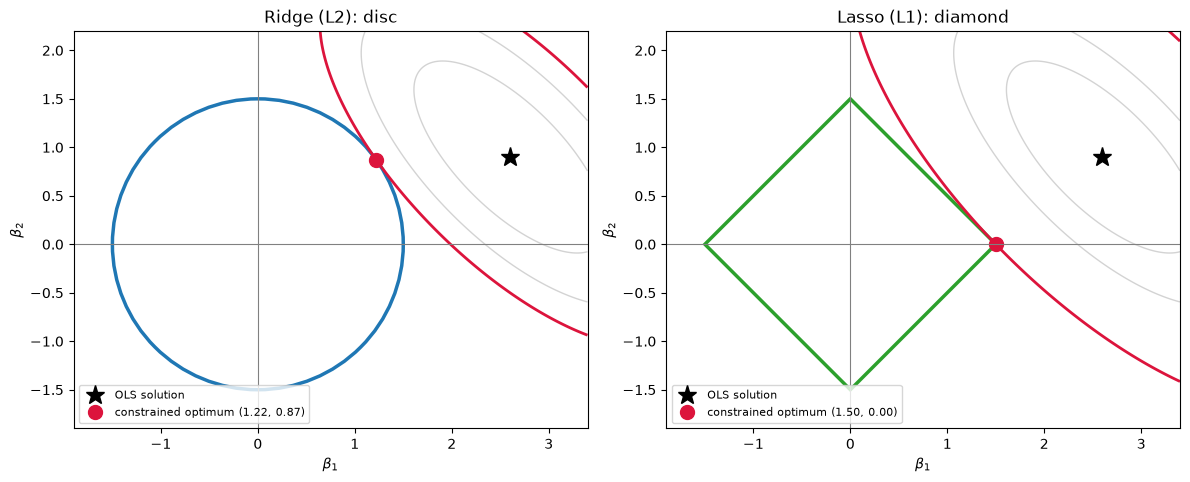

In [8]:
from matplotlib.patches import Circle, Polygon

b_ols = np.array([2.6, 0.9])                          # the unconstrained (OLS) solution
Hm = np.array([[1.0, 0.7], [0.7, 1.0]])                # shape of the RSS ellipses (correlated features)
t = 1.5                                                # size of the budget region
loss = lambda b: np.einsum("...i,ij,...j->...", b - b_ols, Hm, b - b_ols)

g0, g1 = np.meshgrid(np.linspace(-1.9, 3.4, 500), np.linspace(-1.9, 2.2, 500))
Lgrid = loss(np.stack([g0, g1], axis=-1))

theta = np.linspace(0, 2 * np.pi, 200001)
circle_pts = np.column_stack([t * np.cos(theta), t * np.sin(theta)])
corners = [(t, 0), (0, t), (-t, 0), (0, -t)]
diamond_pts = np.vstack([np.array(a)[None] + np.linspace(0, 1, 50001)[:, None] * (np.array(b) - np.array(a))[None]
                         for a, b in zip(corners, corners[1:] + corners[:1])])

fig, axes = plt.subplots(1, 2, figsize=(12, 5.4))
for ax, pts, patch, title in [(axes[0], circle_pts, Circle((0, 0), t, fill=False, lw=2.5, color="tab:blue"), "Ridge (L2): disc"),
                              (axes[1], diamond_pts, Polygon(corners, fill=False, lw=2.5, color="tab:green"), "Lasso (L1): diamond")]:
    best = pts[np.argmin(loss(pts))]
    ax.contour(g0, g1, Lgrid, levels=[0.5, 1.2, float(loss(best))], colors=["lightgrey", "lightgrey", "crimson"], linewidths=[1, 1, 2])
    ax.add_patch(patch)
    ax.plot(*b_ols, "k*", ms=14, label="OLS solution"); ax.plot(*best, "o", color="crimson", ms=10, label=f"constrained optimum ({best[0]:.2f}, {best[1]:.2f})")
    ax.axhline(0, color="grey", lw=0.8); ax.axvline(0, color="grey", lw=0.8)
    ax.set_xlim(-1.9, 3.4); ax.set_ylim(-1.9, 2.2); ax.set_aspect("equal")
    ax.set_xlabel(r"$\beta_1$"); ax.set_ylabel(r"$\beta_2$"); ax.set_title(title); ax.legend(loc="lower left", fontsize=8)
plt.tight_layout(); plt.show()

In the left panel the contact point has both coordinates non-zero (Ridge shrinks both coefficients, 2.6 → 1.22 and 0.9 → 0.87). In the right panel the first contact is at the **corner** $(1.5,\,0)$: Lasso sets $\beta_2$ exactly to zero. This is the single most important picture of the chapter.

### 2.2 Checking the theory numerically

We build a design with **exactly orthonormal columns** ($\mathbf X^{\top}\mathbf X=n\mathbf I$, centred), where the formulas above are exact, and compare them with scikit-learn:

In [9]:
rng = np.random.RandomState(0)
n, p = 200, 5
Z = rng.normal(size=(n, p)); Z -= Z.mean(axis=0)
Q, _ = np.linalg.qr(Z)
X_orth = Q * np.sqrt(n)                                    # centred columns with X'X = n I
y_orth = X_orth @ np.array([3.0, -2.0, 0.4, 0.0, 1.5]) + rng.normal(0, 1, n)
print("X'X = n I   :", np.allclose(X_orth.T @ X_orth / n, np.eye(p)))

soft = lambda b, thr: np.sign(b) * np.maximum(np.abs(b) - thr, 0)
ols = LinearRegression().fit(X_orth, y_orth).coef_

rows = {"OLS": ols}
for a in [0.5, 1.5]:
    lasso = Lasso(alpha=a, tol=1e-12, max_iter=10**6).fit(X_orth, y_orth).coef_
    ridge = Ridge(alpha=a * n).fit(X_orth, y_orth).coef_              # Ridge's alpha is NOT divided by n -> a*n
    rows[f"Lasso, alpha={a}"] = lasso
    rows[f"Ridge, alpha={a}*n"] = ridge
    assert np.allclose(lasso, soft(ols, a), atol=1e-6) and np.allclose(ridge, ols / (1 + a), atol=1e-8)

print("Lasso = soft-threshold(OLS, alpha)   and   Ridge = OLS / (1 + alpha)   -> both verified for alpha = 0.5 and 1.5\n")
pd.DataFrame(rows, index=[f"beta_{j+1}" for j in range(p)]).round(3)

X'X = n I   : True
Lasso = soft-threshold(OLS, alpha)   and   Ridge = OLS / (1 + alpha)   -> both verified for alpha = 0.5 and 1.5



,OLS,"Lasso, alpha=0.5","Ridge, alpha=0.5*n","Lasso, alpha=1.5","Ridge, alpha=1.5*n"
beta_1,3.034,2.534,2.023,1.534,1.214
beta_2,-1.868,-1.368,-1.246,-0.368,-0.747
beta_3,0.400,0.000,0.267,0.000,0.160
beta_4,0.035,0.000,0.023,0.000,0.014
beta_5,1.488,0.988,0.992,0.000,0.595


The table shows both mechanisms side by side. For $\alpha=0.5$, Lasso subtracts 0.5 from every non-zero coefficient (3.03 → 2.53, −1.87 → −1.37) and clips the tiny ones (0.40 → 0 and 0.03 → 0) to exactly zero. Ridge multiplies *every* coefficient by $1/(1+0.5)=0.667$ and keeps all of them non-zero. The assertion in the code confirms that the formulas are exact, and that `Ridge` needs $\alpha\cdot n$ to match Lasso's $\alpha$, which is the note above in numbers.

### 2.3 The book's recipe: Ridge vs. Lasso vs. OLS

The book fits `Ridge(alpha=1.0)` and `Lasso(alpha=10.0, max_iter=10000, tol=0.001)` on the dataset from Section 1.2 and compares the three models on the test set.

In [10]:
ridge_model = Ridge(alpha=1.0)                                # alpha controls regularisation strength
ridge_model.fit(X_train, y_train)

lasso_model = Lasso(alpha=10.0, max_iter=10000, tol=0.001)    # more iterations for convergence
lasso_model.fit(X_train, y_train)

y_pred_ridge = ridge_model.predict(X_test)
y_pred_lasso = lasso_model.predict(X_test)
y_pred_linear = linear_model.predict(X_test)

metrics_df = pd.DataFrame({
    "Model": ["Ridge Regression", "Lasso Regression", "Linear Regression"],
    "Mean Squared Error": [mean_squared_error(y_test, p_) for p_ in (y_pred_ridge, y_pred_lasso, y_pred_linear)],
    "R-squared": [r2_score(y_test, p_) for p_ in (y_pred_ridge, y_pred_lasso, y_pred_linear)],
}).sort_values("Mean Squared Error", ascending=True)

metrics_df.style.format({"Mean Squared Error": "{:,.2f}", "R-squared": "{:.2f}"})

,Model,Mean Squared Error,R-squared
0,Ridge Regression,"45,341,091,794.40",0.09
1,Lasso Regression,"46,377,111,017.93",0.07
2,Linear Regression,"46,550,591,070.53",0.06


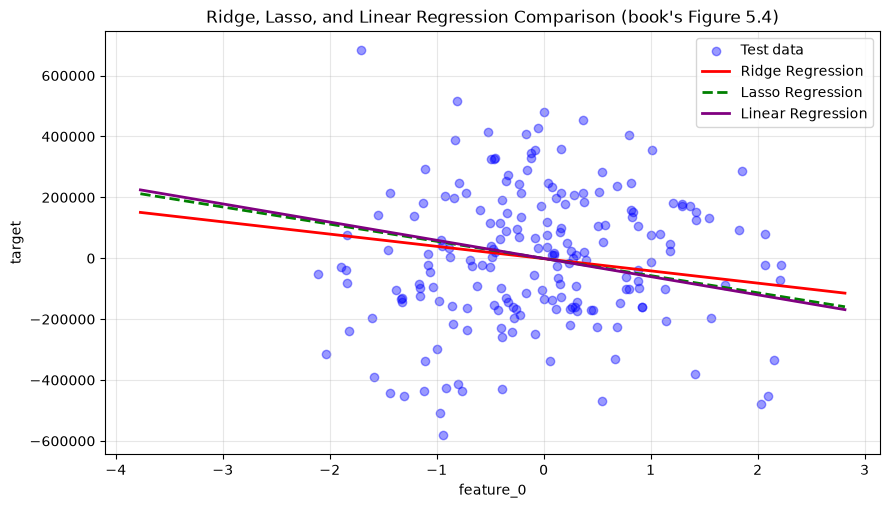

non-zero coefficients (of 100):  Linear = 100 | Ridge = 100 | Lasso(alpha=10) = 100


In [11]:
# The book's Figure 5.4: all three fitted lines against feature_0
plt.figure(figsize=(10, 5.5))
plt.scatter(X_test[:, 0], y_test, color="blue", alpha=0.4, label="Test data")
for model, label, style, color in [(ridge_model, "Ridge Regression", "-", "red"),
                                   (lasso_model, "Lasso Regression", "--", "green"),
                                   (linear_model, "Linear Regression", "-", "purple")]:
    plt.plot(X_line, model.predict(X_line_full), style, color=color, label=label, lw=2)
plt.xlabel("feature_0"); plt.ylabel("target"); plt.title("Ridge, Lasso, and Linear Regression Comparison (book's Figure 5.4)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

nz = lambda m: int((np.abs(m.coef_) > 1e-12).sum())
print("non-zero coefficients (of 100):  Linear =", nz(linear_model), "| Ridge =", nz(ridge_model), "| Lasso(alpha=10) =", nz(lasso_model))

The ranking is the same as in the book: **Ridge** (MSE 4.53 × 10¹⁰, $R^2$ 0.09) < **Lasso** (4.64 × 10¹⁰, 0.07) < **OLS** (4.66 × 10¹⁰, 0.06). In relative terms Ridge lowers the OLS error by 2.6 % and Lasso by only 0.4 %.

Two things stand out:

* **Lasso did no feature selection**: all 100 coefficients are still non-zero, although the book presents "shrinks some coefficients to 0" as Lasso's main virtue. The next cells explain why.
* The three lines in the plot are almost identical, which is unsurprising since they show only the response along `feature_0` and differ by a few per cent.

### 2.4 Is the difference real? Repeated cross-validation

In [12]:
cv_book = RepeatedKFold(n_splits=5, n_repeats=5, random_state=0)       # 25 train/validation splits

def r2_over_folds(model, X_, y_, cv=cv_book):
    return cross_val_score(model, X_, y_, cv=cv, scoring="r2")

book_models = {
    "Linear (OLS)":        LinearRegression(),
    "Ridge(alpha=1)":      Ridge(alpha=1.0),
    "Lasso(alpha=10)":     Lasso(alpha=10.0, max_iter=10000, tol=1e-3),
}
fold_scores = {name: r2_over_folds(m, X, y) for name, m in book_models.items()}
summary = pd.DataFrame({name: {"mean R^2": s.mean(), "std over folds": s.std(),
                               "better than OLS in (% of folds)": 100 * np.mean(s > fold_scores["Linear (OLS)"])}
                        for name, s in fold_scores.items()}).T
summary.round(4)

,mean R^2,std over folds,better than OLS in (% of folds)
Linear (OLS),0.1095,0.0634,0.0
Ridge(alpha=1),0.1331,0.0571,100.0
Lasso(alpha=10),0.1127,0.0625,100.0


In [13]:
# How big is alpha=10 for the Lasso on THIS data? The smallest alpha that sets every coefficient to zero:
X_c = X_train - X_train.mean(axis=0)
alpha_max = np.max(np.abs(X_c.T @ (y_train - y_train.mean()))) / len(y_train)
print(f"alpha_max for the Lasso (all coefficients zero beyond it): {alpha_max:,.0f}")
print(f"the book's alpha = 10 is only {10 / alpha_max:.4%} of alpha_max")

alpha_max for the Lasso (all coefficients zero beyond it): 98,886
the book's alpha = 10 is only 0.0101% of alpha_max


Cross-validation confirms the direction but also its size:

* **Ridge(alpha=1)** beats OLS in 100 % of the 25 splits, but by only **+0.024** in $R^2$ (0.133 vs 0.110): a small and very consistent gain.
* **Lasso(alpha=10)** also beats OLS in every split, but by just **+0.003**: it is practically OLS. The reason is the second cell: the book's `alpha=10` is only **0.01 %** of `alpha_max` ($\approx 98\,886$), the penalty at which *every* coefficient is zero. With a penalty that tiny, Lasso cannot select anything. The same `alpha` of 10 that is "strong" for Ridge on other data is negligible here; `alpha` has meaning only relative to the data's scale (here the target has a standard deviation of 223 821).

### 2.5 Letting cross-validation choose `alpha`: `LassoCV`

Instead of guessing `alpha`, `LassoCV` fits the whole regularization path and picks the `alpha` with the best cross-validated error. We put it in a pipeline with `StandardScaler` (Section 2.6 explains why scaling matters for penalised models).

In [14]:
lasso_cv = make_pipeline(StandardScaler(), LassoCV(cv=5, max_iter=50000, random_state=0)).fit(X_train, y_train)
best_alpha = lasso_cv[-1].alpha_
support = np.where(lasso_cv[-1].coef_ != 0)[0]
useful = sorted(set(kept) | {j + 50 for j in kept})                   # intact informative columns and their copies

print(f"alpha chosen by cross-validation : {best_alpha:,.0f}   (alpha_max was {alpha_max:,.0f})")
print(f"non-zero coefficients            : {len(support)} of 100  -> columns {support.tolist()}")
print(f"columns that really carry signal : {useful}  (the intact informative columns {kept} and their copies)")
print(f"test R^2: LassoCV = {lasso_cv.score(X_test, y_test):.3f}   vs. plain OLS = {linear_model.score(X_test, y_test):.3f}")

alpha chosen by cross-validation : 9,934   (alpha_max was 98,886)
non-zero coefficients            : 14 of 100  -> columns [0, 2, 9, 21, 32, 41, 49, 53, 65, 71, 75, 76, 82, 91]
columns that really carry signal : [3, 21, 25, 53, 71, 75]  (the intact informative columns [3, 21, 25] and their copies)
test R^2: LassoCV = 0.205   vs. plain OLS = 0.065


With a penalty chosen by data, Lasso behaves as advertised:

* The selected `alpha` (≈ 9 934) is about **10 % of `alpha_max`**, roughly **1 000 times** the book's value of 10.
* Only **14 of 100** coefficients stay non-zero, and the test $R^2$ rises from **0.065 (OLS) to 0.205**, close to the 0.23 ceiling. (One split of 200 test rows; Section 2.4's cross-validation gave the same direction.)
* The signal columns are recovered: of the three intact informative features, 3, 21 and 25, the selection contains 53 (the copy of 3), 21 and 71 (copies of 21) and 75 (the copy of 25). Because each informative feature has a near-identical twin, Lasso may pick the original *or* its copy; Section 3.6 shows this arbitrary choice is a general property of Lasso. The remaining 10 selected columns are false positives.

### 2.6 Regularization is not scale-invariant: always standardise

The penalty looks at the *numerical size* of each coefficient, and that size depends on the units of the feature. A feature measured in tiny units needs a huge coefficient to have any effect, so it is penalised heavily; a feature in large units needs only a tiny coefficient and **escapes the penalty**. Demonstration: take five features, and multiply the first one by 1 000 (a unit change, e.g. metres → millimetres):

In [15]:
X5, y5 = make_regression(300, 5, n_informative=5, noise=5, random_state=1)
X5_big = X5.copy(); X5_big[:, 0] *= 1000                                      # feature 0 in 'millimetres'

rows = {}
for label, XX in [("original units", X5), ("feature 0 x 1000", X5_big)]:
    ols_c = LinearRegression().fit(XX, y5).coef_
    ridge_c = Ridge(alpha=1000).fit(XX, y5).coef_
    rows[label] = pd.Series(ridge_c / ols_c, index=[f"feature_{j}" for j in range(5)])

print("Ridge(alpha=1000): remaining fraction of each OLS coefficient (1.0 = not shrunk at all)")
display(pd.DataFrame(rows).round(3))

# the standard remedy: scaling inside a pipeline gives the SAME model whatever the units
p1 = make_pipeline(StandardScaler(), Ridge(alpha=100)).fit(X5, y5)
p2 = make_pipeline(StandardScaler(), Ridge(alpha=100)).fit(X5_big, y5)
print("with StandardScaler in the pipeline, predictions are identical for both unit choices:",
      np.allclose(p1.predict(X5), p2.predict(X5_big)))

Ridge(alpha=1000): remaining fraction of each OLS coefficient (1.0 = not shrunk at all)


,original units,feature 0 x 1000
feature_0,0.244,1.077
feature_1,0.207,0.190
feature_2,0.208,0.197
feature_3,0.200,0.210
feature_4,0.214,0.211


with StandardScaler in the pipeline, predictions are identical for both unit choices: True


With the original units, Ridge keeps roughly **20-24 %** of every OLS coefficient: the shrinkage is uniform. After rescaling only `feature_0` (×1 000), its coefficient is 1 000 times smaller in numerical size (0.09 instead of 93), so $\alpha\beta^2$ hardly touches it: it keeps **108 %** of its OLS value (not shrunk at all; a value slightly above 1 can occur in a finite sample), while the four untouched features are still shrunk to about 19-21 %. Nothing about the *information* in the data changed, only a unit, yet the fitted model did.

With `StandardScaler` in the pipeline, the predictions are identical whatever the units. That is why every regularized model in this notebook is wrapped in a pipeline with a scaler (the sole exception is the book's own recipe code in Sections 1.3-3.5, which we reproduce as written).

### 2.7 A dataset where regularization visibly helps

The book's data hides the benefits of regularization (the signal is mostly gone, Section 1.2b). We build the dataset the recipe *intended*: **50 original features** (10 informative) and **50 noisy copies** of them, with the target generated from the originals only, and a realistic **150 samples** (so that 100 correlated features are a lot).

In [16]:
def make_collinear_data(n_samples, seed=123):
    base, y_, coef_ = make_regression(n_samples=n_samples, n_features=50, n_informative=10,
                                      noise=20, random_state=seed, coef=True)
    rng_ = np.random.RandomState(seed)
    X_ = np.hstack([base, base + rng_.normal(0, 0.1, size=base.shape)])      # 50 originals + 50 noisy copies
    return X_, y_, coef_

X_fix, y_fix, coef_fix = make_collinear_data(150)
print("shape:", X_fix.shape, "| true noise variance = 20^2 = 400 | variance of the target:", round(y_fix.var()))
print("correlation of feature_0 with its copy feature_50: %.4f" % np.corrcoef(X_fix[:, 0], X_fix[:, 50])[0, 1])

shape: (150, 100) | true noise variance = 20^2 = 400 | variance of the target: 32532
correlation of feature_0 with its copy feature_50: 0.9949


In [17]:
inner = KFold(5, shuffle=True, random_state=1)                         # the CV used *inside* the CV-estimators
fix_models = {
    "OLS":              LinearRegression(),
    "RidgeCV":          make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 4, 40), cv=inner)),
    "LassoCV":          make_pipeline(StandardScaler(), LassoCV(cv=inner, max_iter=50000, random_state=0)),
    "ElasticNetCV":     make_pipeline(StandardScaler(), ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9, 1.0], cv=inner,
                                                                      max_iter=50000, random_state=0)),
}
cv_fix = RepeatedKFold(n_splits=5, n_repeats=10, random_state=0)       # outer loop: honest (nested) estimate
rows = {}
for name, m in fix_models.items():
    res = cross_validate(m, X_fix, y_fix, cv=cv_fix, scoring=("r2", "neg_mean_squared_error"))
    rows[name] = {"mean R^2": res["test_r2"].mean(), "std R^2": res["test_r2"].std(),
                  "mean test MSE": -res["test_neg_mean_squared_error"].mean()}
fix_table = pd.DataFrame(rows).T
print("noise floor: no model can have a test MSE below 400 on average\n")
fix_table.round(3)

noise floor: no model can have a test MSE below 400 on average



,mean R^2,std R^2,mean test MSE
OLS,0.907,0.044,2760.687
RidgeCV,0.969,0.013,938.658
LassoCV,0.977,0.008,680.239
ElasticNetCV,0.977,0.008,680.239


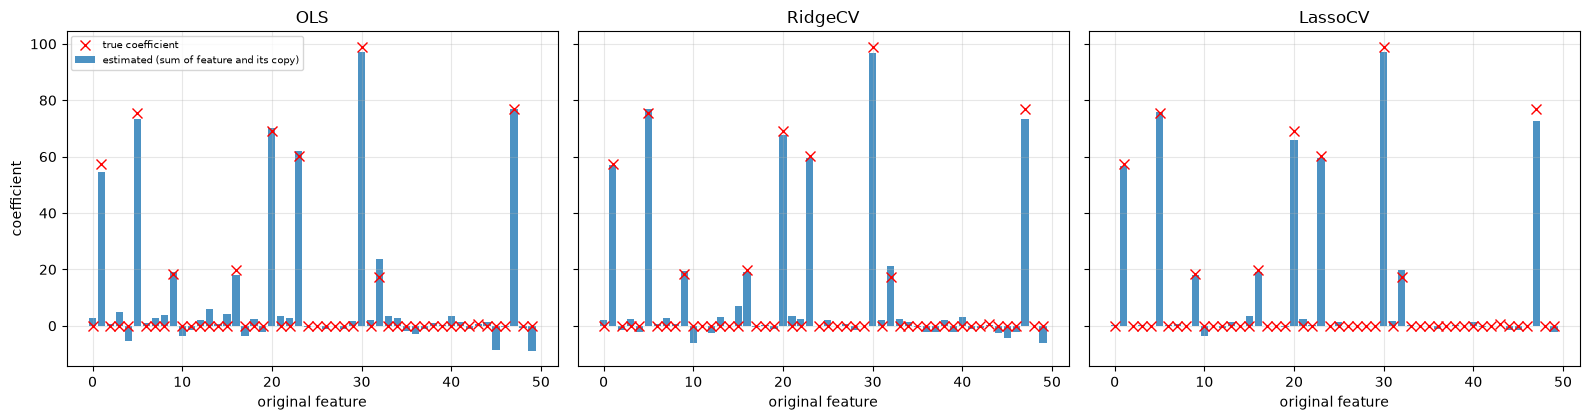

,largest |individual coefficient|,non-zero coefficients (of 100),chosen alpha
OLS,145.1011,100.0,NaN
RidgeCV,55.7464,100.0,1.1253
LassoCV,79.7769,39.0,1.0625


In [18]:
# What do the fitted models look like? Fit each on all 150 rows. Because each feature has a near-twin,
# only the SUM of the two weights is meaningful, so we compare that sum with the true coefficient.
def raw_coef(model):
    if hasattr(model, "steps"):
        return model[-1].coef_ / model[0].scale_          # back to the original feature units
    return model.coef_

fitted = {n_: m.fit(X_fix, y_fix) for n_, m in fix_models.items()}
fig, axes = plt.subplots(1, 3, figsize=(16, 4.3), sharey=True)
stats = {}
for ax, name in zip(axes, ["OLS", "RidgeCV", "LassoCV"]):
    w = raw_coef(fitted[name])
    effective = w[:50] + w[50:]
    ax.bar(np.arange(50), effective, color="tab:blue", alpha=0.8, label="estimated (sum of feature and its copy)")
    ax.plot(np.arange(50), coef_fix, "rx", ms=7, label="true coefficient")
    ax.set_title(name); ax.set_xlabel("original feature"); ax.grid(alpha=0.3)
    stats[name] = {"largest |individual coefficient|": np.abs(w).max(), "non-zero coefficients (of 100)": int((np.abs(w) > 1e-8).sum())}
axes[0].set_ylabel("coefficient"); axes[0].legend(fontsize=7, loc="upper left")
plt.tight_layout(); plt.show()

stats["LassoCV"]["chosen alpha"] = fitted["LassoCV"][-1].alpha_
stats["RidgeCV"]["chosen alpha"] = fitted["RidgeCV"][-1].alpha_
pd.DataFrame(stats).T

On this dataset the benefits of regularization are large and consistent:

| | OLS | RidgeCV | LassoCV | ElasticNetCV |
|---|---|---|---|---|
| test MSE (floor = 400) | 2 761 | 939 | 680 | 680 |
| times the noise floor | 6.9 × | 2.3 × | 1.7 × | 1.7 × |

* Regularization removes **66 %** (Ridge) to **75 %** (Lasso) of OLS's test error, and the fold-to-fold spread of $R^2$ drops from 0.044 to 0.013 and 0.008.
* `ElasticNetCV` has the same numbers as `LassoCV` because cross-validation chose `l1_ratio=1.0` (pure Lasso): with this sparse truth, the extra Ridge component did not improve prediction.
* In the bar charts the **summed** coefficient of each feature and its twin tracks the true value for all three models. OLS also shows spurious bars on features that carry no signal (some near -9), Lasso is the cleanest, and both penalised models slightly under-estimate the largest true coefficients (e.g. around 73 and 72 against a true value near 77 for feature 47): shrinkage bias, the price paid for lower variance.
* The table under the charts shows OLS's largest individual coefficient is **145**, larger than any true coefficient (the true ones are at most about 100), because twin coefficients take large offsetting values; Ridge's largest is 56. LassoCV keeps **39** of 100 coefficients, more than the 10 to 20 an ideal sparse model would need: cross-validated Lasso typically keeps some weak false positives.

### 2.8 Ridge or Lasso? The book's rule of thumb, tested

The book says: *Ridge is useful when you want to keep all features but reduce their impact; Lasso is beneficial when you suspect many features are irrelevant or redundant*. A direct test: **more features than samples** (50 rows, 200 features) where only 5 features matter (a *sparse* truth).

In [19]:
X_sp, y_sp, coef_sp = make_regression(n_samples=50, n_features=200, n_informative=5, noise=5, random_state=0, coef=True)
cv_sp = RepeatedKFold(n_splits=5, n_repeats=5, random_state=0)
inner_sp = KFold(5, shuffle=True, random_state=1)

sp_models = {
    "OLS":      LinearRegression(),
    "RidgeCV":  make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-2, 5, 40), cv=inner_sp)),
    "LassoCV":  make_pipeline(StandardScaler(), LassoCV(cv=inner_sp, max_iter=50000, random_state=0)),
}
print("OLS R^2 on its own training data:", round(LinearRegression().fit(X_sp, y_sp).score(X_sp, y_sp), 4), "(200 features can fit any 50 points exactly)\n")
rows = {n_: {"CV R^2": (s := cross_val_score(m, X_sp, y_sp, cv=cv_sp, scoring="r2")).mean(), "std": s.std()} for n_, m in sp_models.items()}
display(pd.DataFrame(rows).T.round(3))

lasso_sp = sp_models["LassoCV"].fit(X_sp, y_sp)
chosen = np.where(lasso_sp[-1].coef_ != 0)[0]; truth = np.where(coef_sp != 0)[0]
print(f"true informative features : {truth.tolist()}")
print(f"LassoCV selected {len(chosen)} features; true ones found: {len(set(chosen) & set(truth))} of {len(truth)}; false positives: {len(set(chosen) - set(truth))}")

OLS R^2 on its own training data: 1.0 (200 features can fit any 50 points exactly)



,CV R^2,std
OLS,0.001,0.373
RidgeCV,-0.065,0.304
LassoCV,0.993,0.005


true informative features : [77, 85, 98, 166, 180]
LassoCV selected 27 features; true ones found: 5 of 5; false positives: 22


This is the textbook situation for the Lasso:

* **OLS** fits its training data perfectly (training $R^2=1.0$, since 200 features can interpolate any 50 points) but is no better than the mean on new data (CV $R^2\approx0.00$, with a huge spread of ±0.37).
* **Ridge** fails too (-0.07). It can shrink but not remove the 195 irrelevant features, and their combined noise swamps the 5 real ones.
* **Lasso** reaches **0.993**: it finds all **5 of 5** true features, plus 22 false positives that carry small weights.

So the book's rule of thumb (Lasso when many features are irrelevant) is confirmed, for a **sparse truth**. The rule cuts both ways: when *all* features have small effects, Ridge is expected to do better than Lasso. We did not test that case here.

## 3. ElasticNet and regularization

### 3.1 Theory

**ElasticNet** keeps both penalties, and uses two numbers to control them: the overall strength `alpha` and the mixing proportion `l1_ratio` $=\rho\in[0,1]$. The objective minimised by scikit-learn is

$$\frac1{2n}\lVert\mathbf y-\mathbf X\boldsymbol\beta\rVert_2^2\;+\;\alpha\rho\,\lVert\boldsymbol\beta\rVert_1\;+\;\frac{\alpha(1-\rho)}{2}\,\lVert\boldsymbol\beta\rVert_2^2 .$$

* `l1_ratio=1` is the Lasso; `l1_ratio` close to 0 behaves like Ridge (the book states this correctly).
* The L1 part produces **sparsity** (some coefficients exactly 0); the L2 part adds **stability** and the **grouping effect**: when several features are strongly correlated, Lasso tends to keep one arbitrarily and drop the others, while ElasticNet tends to keep them together and give them similar weights (demonstrated in Section 3.6).

> **📝 Note on notation.** The book writes the penalty as $\alpha(\lambda_1\sum|\beta_j|+\lambda_2\sum\beta_j^2)$ with two extra constants $\lambda_1,\lambda_2$. That is not how scikit-learn is parameterised: there are only **two** knobs, $\alpha$ and $\rho$, and the weights are fixed as $\lambda_1=\rho$ and $\lambda_2=(1-\rho)/2$ (and the error term is divided by $2n$, as for the Lasso).

With orthonormal features ($\mathbf X^{\top}\mathbf X=n\mathbf I$) the solution is *soft-threshold, then shrink*:

$$\hat\beta^{\text{enet}}_j=\frac{\operatorname{sign}(\hat\beta^{\text{ols}}_j)\,\max\bigl(\lvert\hat\beta^{\text{ols}}_j\rvert-\alpha\rho,\,0\bigr)}{1+\alpha(1-\rho)} .$$

Let's verify with the design from Section 2.2:

In [20]:
rows = {"OLS": ols}
for a, rho in [(0.5, 0.3), (1.5, 0.5)]:
    en = ElasticNet(alpha=a, l1_ratio=rho, tol=1e-12, max_iter=10**6).fit(X_orth, y_orth).coef_
    pred = soft(ols, a * rho) / (1 + a * (1 - rho))
    assert np.allclose(en, pred, atol=1e-6)
    rows[f"ElasticNet alpha={a}, l1_ratio={rho}"] = en
print("formula verified (soft-threshold with alpha*rho, then divide by 1 + alpha*(1-rho))\n")
pd.DataFrame(rows, index=[f"beta_{j+1}" for j in range(p)]).round(3)

formula verified (soft-threshold with alpha*rho, then divide by 1 + alpha*(1-rho))



,OLS,"ElasticNet alpha=0.5, l1_ratio=0.3","ElasticNet alpha=1.5, l1_ratio=0.5"
beta_1,3.034,2.136,1.305
beta_2,-1.868,-1.273,-0.639
beta_3,0.400,0.185,0.000
beta_4,0.035,0.000,0.000
beta_5,1.488,0.991,0.422


### 3.2 The book's coefficient-path experiment

The book trains `ElasticNet` for 7 values of `alpha` (from $10^{-4}$ to $10^{2}$) and 5 values of `l1_ratio`, and plots every coefficient against $\log_{10}(\alpha)$. We reproduce it and, in addition, **count the non-zero coefficients** in each setting, since the book's text claims that "some coefficients go to exactly 0".

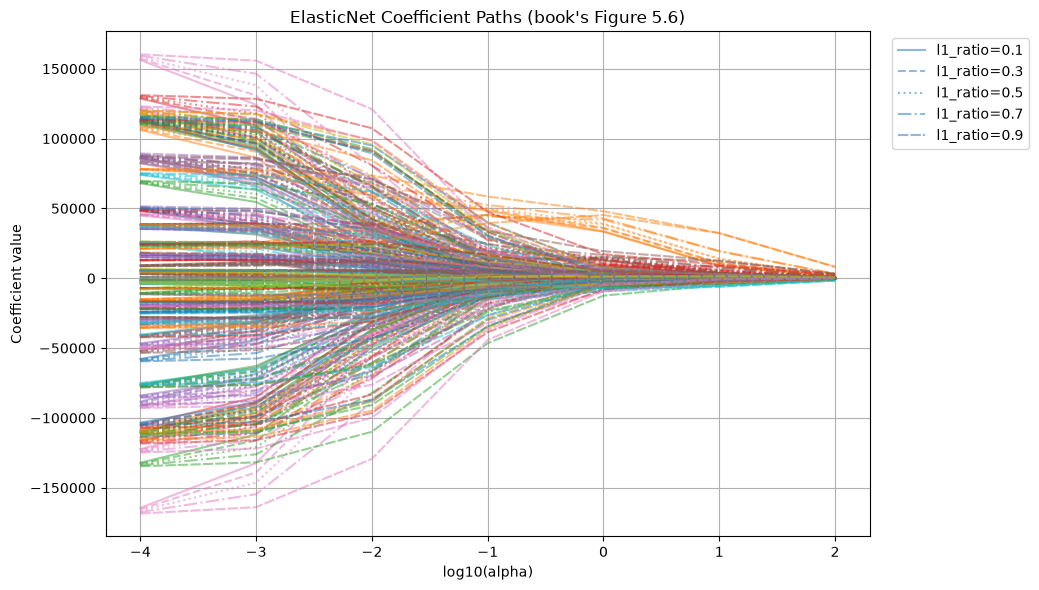

number of NON-ZERO coefficients (of 100) for each alpha:


,alpha=0.0001,alpha=0.001,alpha=0.01,alpha=0.1,alpha=1,alpha=10,alpha=100
l1_ratio=0.1,100,100,100,100,100,100,98
l1_ratio=0.3,100,100,100,100,100,100,98
l1_ratio=0.5,100,100,100,100,100,100,99
l1_ratio=0.7,100,100,100,100,100,100,97
l1_ratio=0.9,100,100,100,100,100,100,100


In [21]:
alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]
line_styles = ["solid", "dashed", "dotted", "dashdot", (0, (5, 1))]

nonzero_counts = {}
plt.figure(figsize=(10.5, 6))
for l1_ratio, ls in zip(l1_ratios, line_styles):
    coefs = []
    for alpha in alphas:
        elastic = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=123, max_iter=10000, tol=1e-4)
        elastic.fit(X_train, y_train)
        coefs.append(elastic.coef_)
    coefs = np.array(coefs)
    nonzero_counts[f"l1_ratio={l1_ratio}"] = (np.abs(coefs) > 1e-12).sum(axis=1)
    for j in range(X_train.shape[1]):
        plt.plot(np.log10(alphas), coefs[:, j], linestyle=ls, alpha=0.5, label=f"l1_ratio={l1_ratio}" if j == 0 else None)
plt.xlabel("log10(alpha)"); plt.ylabel("Coefficient value"); plt.title("ElasticNet Coefficient Paths (book's Figure 5.6)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left"); plt.grid(True); plt.tight_layout(); plt.show()

print("number of NON-ZERO coefficients (of 100) for each alpha:")
pd.DataFrame(nonzero_counts, index=[f"alpha={a:g}" for a in alphas]).T

**The book's claim is not supported by its own grid.** Every setting with `alpha` ≤ 10 keeps **all 100** coefficients non-zero, and even at `alpha=100` at most 3 of 100 coefficients are zero. The reason is again the scale of `alpha`: the smallest `alpha` that zeroes everything is `alpha_max` ≈ 98 886 for `l1_ratio=1` and ≈ 98 886 / `l1_ratio` in general (about 989 000 for `l1_ratio=0.1`), so the largest `alpha` in the grid is about 0.1 % of that or less.

The visible shrinkage in the book's Figure 5.6 comes almost entirely from the **L2 part**: by Section 3.5 the L2 part equals a Ridge with `alpha` = (training rows) × `alpha` × (1 − `l1_ratio`), for example 800 × 100 × 0.5 = 40 000 at the right edge, which is a strong Ridge penalty. So the plot illustrates *Ridge-like shrinkage*, not feature selection. (The book itself admits that with 100 features × 5 settings the plot is hard to read.)

### 3.3 A readable coefficient path

To see what a coefficient path *should* look like, we use a small problem: 200 samples, 20 features, **5 informative** (coloured), the rest pure noise (grey). The three panels show how each coefficient changes as the penalty grows (moving **right**, because the x axis is $\log_{10}\alpha$): Ridge, Lasso and ElasticNet with `l1_ratio=0.5`.

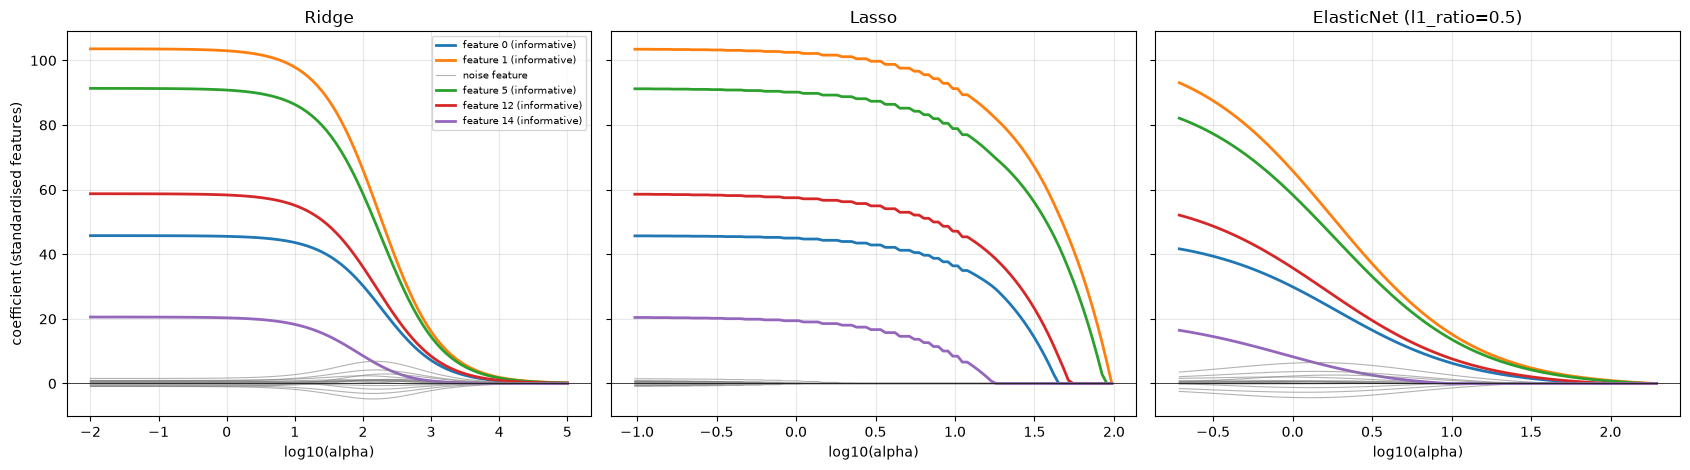

first features to enter the Lasso path (largest alpha first); true informative features: [0, 1, 5, 12, 14]


,enters the Lasso path at alpha,truly informative?
feature,,
1,90.337,yes
5,84.248,yes
12,51.694,yes
0,41.931,yes
14,16.927,yes
17,2.238,no
4,1.039,no
15,1.039,no


In [22]:
Xp_, yp_, cp_ = make_regression(n_samples=200, n_features=20, n_informative=5, noise=10, random_state=3, coef=True)
Xp_s = StandardScaler().fit_transform(Xp_)
true_idx = np.where(cp_ != 0)[0]

alphas_l, coefs_l, _ = lasso_path(Xp_s, yp_, n_alphas=100)
alphas_e, coefs_e, _ = enet_path(Xp_s, yp_, l1_ratio=0.5, n_alphas=100)
alphas_r = np.logspace(-2, 5, 100)
coefs_r = np.array([Ridge(alpha=a).fit(Xp_s, yp_).coef_ for a in alphas_r]).T

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), sharey=True)
palette = plt.cm.tab10(np.arange(len(true_idx)))
for ax, (a_, c_, title) in zip(axes, [(alphas_r, coefs_r, "Ridge"), (alphas_l, coefs_l, "Lasso"), (alphas_e, coefs_e, "ElasticNet (l1_ratio=0.5)")]):
    for j in range(20):
        if j in true_idx:
            ax.plot(np.log10(a_), c_[j], color=palette[list(true_idx).index(j)], lw=2, label=f"feature {j} (informative)")
        else:
            ax.plot(np.log10(a_), c_[j], color="grey", lw=0.8, alpha=0.6, label="noise feature" if j == min(set(range(20)) - set(true_idx)) else None)
    ax.axhline(0, color="k", lw=0.5); ax.set_xlabel("log10(alpha)"); ax.set_title(title); ax.grid(alpha=0.3)
axes[0].set_ylabel("coefficient (standardised features)"); axes[0].legend(fontsize=7, loc="upper right")
plt.tight_layout(); plt.show()

order = np.argsort(-np.array([alphas_l[np.nonzero(c_)[0][0]] if np.any(c_) else 0 for c_ in coefs_l]))
entry = pd.DataFrame({"feature": order[:8],
                      "enters the Lasso path at alpha": [alphas_l[np.nonzero(coefs_l[j])[0][0]] for j in order[:8]],
                      "truly informative?": ["yes" if j in true_idx else "no" for j in order[:8]]}).set_index("feature")
print("first features to enter the Lasso path (largest alpha first); true informative features:", true_idx.tolist())
entry.round(3)

This is how coefficient paths are meant to be read:

* **Lasso:** the five truly informative features enter the model first, in the order 1, 5, 12, 0, 14, at `alpha` ≈ 90, 84, 52, 42 and 17. The first *noise* feature (17) enters only at `alpha` ≈ 2.2, about **7.5 times below** the weakest informative one. A Lasso path is therefore also a **feature ranking**, and here it ranks all 5 true features ahead of every noise feature.
* **Ridge:** every curve declines smoothly and simultaneously; **nothing reaches zero**. The grey noise features keep small non-zero values over the whole range.
* **ElasticNet:** the curves are smoother and decay more gradually than the Lasso's, as expected from the added L2 part. (The three panels use different `alpha` ranges, so their x axes are not directly comparable.)

### 3.4 The book's ElasticNet model and the comparison table

The book then fits a "balanced" model, `alpha=1.0, l1_ratio=0.5`, and adds it to the metrics table. It states that its performance is better than the three previous models.

In [23]:
elastic_model = ElasticNet(alpha=1.0, l1_ratio=0.5, random_state=123, max_iter=10000, tol=1e-4)
elastic_model.fit(X_train, y_train)
elastic_pred = elastic_model.predict(X_test)

new_row = pd.DataFrame({"Model": ["ElasticNet Regression"],
                        "Mean Squared Error": [mean_squared_error(y_test, elastic_pred)],
                        "R-squared": [r2_score(y_test, elastic_pred)]})
metrics_df = metrics_df[~metrics_df["Model"].str.contains("ElasticNet")]
metrics_df = pd.concat([metrics_df, new_row], ignore_index=True).sort_values("Mean Squared Error", ascending=True)
metrics_df.style.format({"Mean Squared Error": "{:,.2f}", "R-squared": "{:.2f}"})

,Model,Mean Squared Error,R-squared
3,ElasticNet Regression,"42,616,635,365.79",0.14
0,Ridge Regression,"45,341,091,794.40",0.09
1,Lasso Regression,"46,377,111,017.93",0.07
2,Linear Regression,"46,550,591,070.53",0.06


The book's claim is reproduced: **ElasticNet** has the lowest MSE (4.26 × 10¹⁰, $R^2$ = **0.14**) and the ordering ElasticNet < Ridge < Lasso < OLS holds, with an MSE 8.4 % below OLS's. The next section checks whether this says anything about *ElasticNet* itself.

### 3.5 Is ElasticNet really "better"? Three checks

**(a) Repeated cross-validation, with paired comparisons.** All models see the *same* 25 train/validation splits, so we can compare them fold by fold.

In [24]:
fold_scores["ElasticNet(alpha=1, l1_ratio=0.5)"] = r2_over_folds(ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000, tol=1e-4), X, y)

ref = fold_scores["Ridge(alpha=1)"]
rows = {}
for name, s in fold_scores.items():
    d = s - ref
    rows[name] = {"mean R^2": s.mean(), "std over folds": s.std(),
                  "better than OLS (% folds)": 100 * np.mean(s > fold_scores["Linear (OLS)"]),
                  "mean gain vs Ridge(1)": d.mean(), "std. error of that gain": d.std() / np.sqrt(len(d))}
pd.DataFrame(rows).T.round(4)

,mean R^2,std over folds,better than OLS (% folds),mean gain vs Ridge(1),std. error of that gain
Linear (OLS),0.1095,0.0634,0.0,-0.0236,0.0018
Ridge(alpha=1),0.1331,0.0571,100.0,0.0000,0.0000
Lasso(alpha=10),0.1127,0.0625,100.0,-0.0204,0.0016
"ElasticNet(alpha=1, l1_ratio=0.5)",0.1828,0.0344,96.0,0.0497,0.0058


**(b) Ridge with a better `alpha`.** The book compares ElasticNet at `alpha=1` with Ridge at `alpha=1`, but (Section 2.1) these are different scales. Ridge's penalty is *not* divided by $n$; ElasticNet's is. Working through the algebra, the L2 part of `ElasticNet(alpha=a, l1_ratio=ρ)` equals the penalty of **`Ridge(alpha = n_train · a · (1 − ρ))`**, which for the 800 training rows of each cross-validation fold is $800\times1\times0.5=400$. So a fair "equivalent" Ridge is `alpha=400`, not 1. We sweep Ridge's `alpha`:

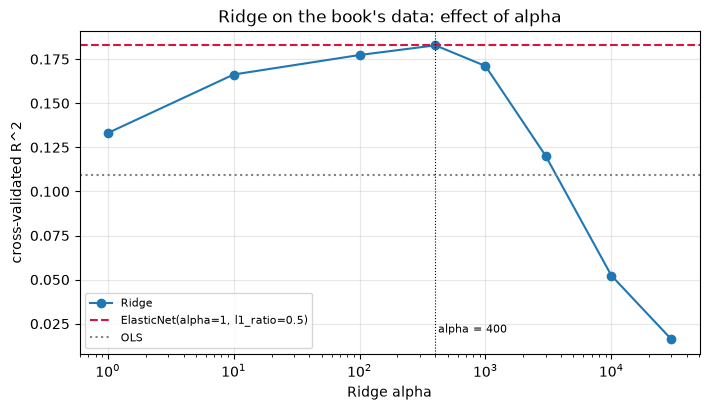

Ridge alpha,1,10,100,400,1000,3000,10000,30000
CV R^2,0.1331,0.1663,0.1773,0.1828,0.1711,0.1203,0.0523,0.0162


In [25]:
n_train_fold = int(len(y) * 0.8)
equiv_alpha = n_train_fold * 1.0 * (1 - 0.5)
ridge_alphas = [1, 10, 100, 400, 1000, 3000, 10000, 30000]
ridge_cv = {a: r2_over_folds(Ridge(alpha=a), X, y).mean() for a in ridge_alphas}

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.semilogx(list(ridge_cv), list(ridge_cv.values()), "o-", label="Ridge")
ax.axhline(fold_scores["ElasticNet(alpha=1, l1_ratio=0.5)"].mean(), color="crimson", ls="--", label="ElasticNet(alpha=1, l1_ratio=0.5)")
ax.axhline(fold_scores["Linear (OLS)"].mean(), color="grey", ls=":", label="OLS")
ax.axvline(equiv_alpha, color="k", lw=0.8, ls=":"); ax.text(equiv_alpha * 1.05, 0.02, f"alpha = {equiv_alpha:.0f}", fontsize=8)
ax.set_xlabel("Ridge alpha"); ax.set_ylabel("cross-validated R^2"); ax.set_title("Ridge on the book's data: effect of alpha"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.show()
pd.Series(ridge_cv, name="CV R^2").rename_axis("Ridge alpha").round(4).to_frame().T

**(c) Is the equivalence exact? And how large are the coefficients?**

In [26]:
n_tr = len(y_train)
en_ridge_like = ElasticNet(alpha=0.5, l1_ratio=1e-9, tol=1e-12, max_iter=10**6).fit(X_train, y_train)   # (almost) pure L2 part
ridge_equiv = Ridge(alpha=n_tr * 0.5).fit(X_train, y_train)
print(f"ElasticNet(alpha=0.5, l1_ratio~0)  vs  Ridge(alpha = n * 0.5 = {n_tr * 0.5:.0f}):  max coefficient difference = {np.abs(en_ridge_like.coef_ - ridge_equiv.coef_).max():.2e}\n")

size = {name: {"largest |coefficient|": np.abs(m.coef_).max(), "L2 norm of coefficients": np.linalg.norm(m.coef_), "non-zero": int((np.abs(m.coef_) > 1e-12).sum())}
        for name, m in [("OLS", linear_model), ("Ridge(alpha=1)", ridge_model), ("Lasso(alpha=10)", lasso_model), ("ElasticNet(alpha=1, l1_ratio=.5)", elastic_model)]}
pd.DataFrame(size).T.style.format({"largest |coefficient|": "{:,.0f}", "L2 norm of coefficients": "{:,.0f}"})

ElasticNet(alpha=0.5, l1_ratio~0)  vs  Ridge(alpha = n * 0.5 = 400):  max coefficient difference = 8.26e-06



,largest |coefficient|,L2 norm of coefficients,non-zero
OLS,"168,983","686,614",100.000000
Ridge(alpha=1),"122,267","522,352",100.000000
Lasso(alpha=10),"165,217","668,007",100.000000
"ElasticNet(alpha=1, l1_ratio=.5)","39,109","66,949",100.000000


The three checks give a clear and somewhat deflating answer:

* **(a)** ElasticNet's advantage is real in this setting: mean $R^2$ 0.183 against Ridge(1)'s 0.133, a gain of **+0.050** (standard error 0.006), and it beats OLS in 96 % of the splits.
* **(b)** But **Ridge with a suitable `alpha` does exactly as well**: at `alpha=400` the cross-validated $R^2$ is **0.1828**, identical to ElasticNet's 0.1828 to four decimals. Ridge improves steadily from `alpha=1` (0.133) through 10 (0.166) and 100 (0.177) to the best value 400, and then declines (0.171 at 1 000, 0.120 at 3 000): the usual U shape.
* **(c)** The equivalence is exact: `ElasticNet(alpha=0.5, l1_ratio≈0)` and `Ridge(alpha=800×0.5=400)` give the same coefficients to within $10^{-5}$. The size table shows how different the *effective* strengths were: the coefficient vector's L2 norm is shrunk by only 3 % by Lasso(10), by 24 % by Ridge(1), but by a factor of about **10** by ElasticNet(1, 0.5).

So the book's conclusion that "ElasticNet is better than Ridge and Lasso" holds in this run **only because the three `alpha` values are not comparable**: the ElasticNet model was simply regularized far more strongly. The L1 part contributed essentially nothing here (its threshold `alpha × l1_ratio` = 0.5 is minuscule against `alpha_max` ≈ 98 886). A fair comparison tunes each model's `alpha` (Section 2.7).

### 3.6 The grouping effect: two nearly identical features

Take three features: $x_1$ and $x_2$ are almost the same variable (correlation 0.998), $x_3$ is independent. The true model is $y=3x_1+3x_2+2x_3+\text{noise}$. We refit each model on 300 **bootstrap resamples** of the data and look at how the estimated coefficients of $x_1$ and $x_2$ behave.

correlation(x1, x2) = 0.9976


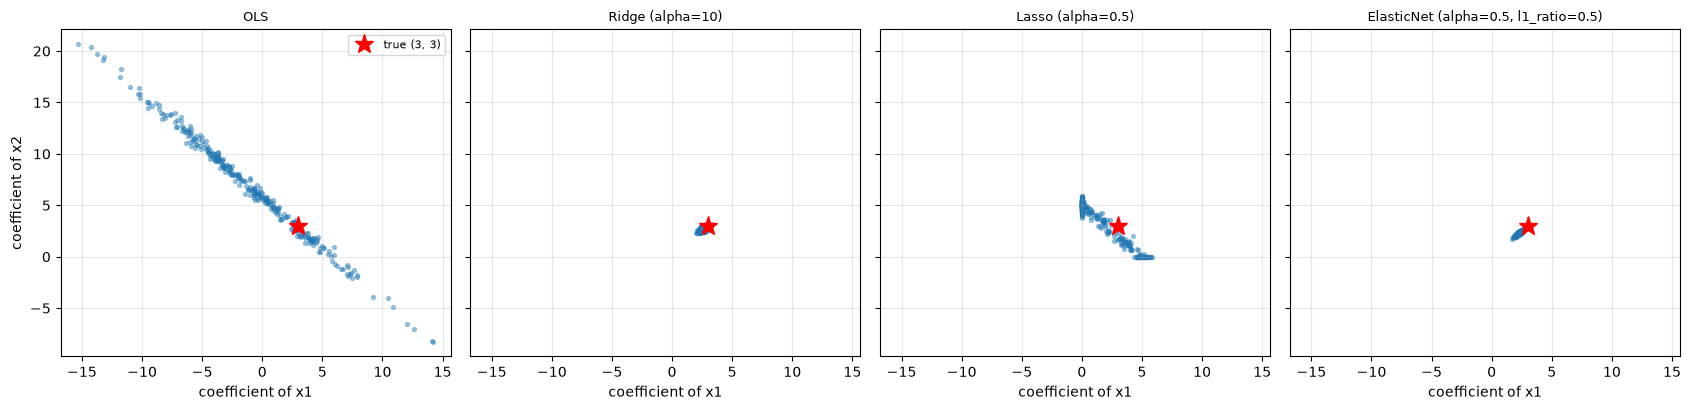

,mean b1,mean b2,std b1,std b2,mean of b1 + b2,std of b1 + b2,"corr(b1, b2) across resamples"
OLS,-1.13,6.89,5.03,5.07,5.76,0.38,-1.00
Ridge (alpha=10),2.62,2.74,0.20,0.19,5.36,0.35,0.62
Lasso (alpha=0.5),1.45,3.57,1.95,1.96,5.02,0.39,-0.98
"ElasticNet (alpha=0.5, l1_ratio=0.5)",2.28,2.31,0.18,0.17,4.59,0.35,0.92


In [27]:
rng = np.random.RandomState(1)
n_b = 100
z = rng.normal(size=n_b)
x1 = z + rng.normal(0, 0.05, n_b); x2 = z + rng.normal(0, 0.05, n_b); x3 = rng.normal(size=n_b)
X_g = np.column_stack([x1, x2, x3])
y_g = 3 * x1 + 3 * x2 + 2 * x3 + rng.normal(0, 3, n_b)
print("correlation(x1, x2) = %.4f" % np.corrcoef(x1, x2)[0, 1])

group_models = {"OLS": LinearRegression(), "Ridge (alpha=10)": Ridge(alpha=10),
                "Lasso (alpha=0.5)": Lasso(alpha=0.5), "ElasticNet (alpha=0.5, l1_ratio=0.5)": ElasticNet(alpha=0.5, l1_ratio=0.5)}
boot = {name: [] for name in group_models}
for _ in range(300):
    idx = rng.randint(0, n_b, n_b)
    for name, m in group_models.items():
        boot[name].append(m.fit(X_g[idx], y_g[idx]).coef_.copy())
boot = {k: np.array(v) for k, v in boot.items()}

fig, axes = plt.subplots(1, 4, figsize=(17, 4.2), sharex=True, sharey=True)
rows = {}
for ax, (name, B) in zip(axes, boot.items()):
    ax.scatter(B[:, 0], B[:, 1], s=8, alpha=0.4); ax.plot([3], [3], "r*", ms=14, label="true (3, 3)")
    ax.set_title(name, fontsize=9); ax.set_xlabel("coefficient of x1"); ax.grid(alpha=0.3)
    rows[name] = {"mean b1": B[:, 0].mean(), "mean b2": B[:, 1].mean(), "std b1": B[:, 0].std(), "std b2": B[:, 1].std(),
                  "mean of b1 + b2": (B[:, 0] + B[:, 1]).mean(), "std of b1 + b2": (B[:, 0] + B[:, 1]).std(),
                  "corr(b1, b2) across resamples": np.corrcoef(B[:, 0], B[:, 1])[0, 1]}
axes[0].set_ylabel("coefficient of x2"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()
pd.DataFrame(rows).T.round(2)

The four behaviours are the classical picture of correlated features:

* **OLS:** the individual coefficients are wildly unstable (standard deviation about 5.0, larger than the true value 3), and `b1` and `b2` are perfectly *negatively* correlated across resamples (-1.00): the data can only pin down their **sum** (mean 5.76, std 0.38; true value 6). One coefficient is high exactly when the other is low.
* **Ridge:** the weight is split evenly and **stably** (2.62 and 2.74, std about 0.2), at the price of a sum that is shrunk below the truth (5.36).
* **Lasso:** the sum is as stable as OLS's (std 0.39), but the *split* is arbitrary: in every resample it favours one of the twins (means 1.45 and 3.57, std about 1.95, correlation -0.98). Which twin "wins" is essentially chance.
* **ElasticNet:** the even, stable split of Ridge (2.28 and 2.31, std about 0.18, correlation **+0.92**): this is the **grouping effect**. Its sum (4.59) is shrunk more because `alpha=0.5` is a strong penalty for only 100 rows.

Consequence for interpretation: if you use a Lasso to decide *which* of two highly correlated features "matters", the answer can change from sample to sample, as it did for the twin columns in Section 2.5.

## 4. Regularization theory and practice

### 4.1 Model complexity and over-fitting

**Model complexity** is a model's capacity to fit many different functions. A very flexible model can follow every wiggle of the training data, including the noise, and then fails on new data (**over-fitting**); a model that is too rigid cannot capture the real pattern (**under-fitting**). Regularization is one way of controlling complexity *without changing the model's form*: the model keeps all its features but is not allowed to use them freely.

| Technique | Penalty | Effect on coefficients | Typical use |
|-----------|---------|------------------------|-------------|
| **L1 (Lasso)** | $\alpha\sum\lvert\beta_j\rvert$ | some become exactly **0** (sparse model) | many irrelevant features; wanting a short list of features |
| **L2 (Ridge)** | $\alpha\sum\beta_j^2$ | all shrink, **none is 0** | correlated features; keep everything but stabilise |
| **ElasticNet** | mix of both | sparse *and* stable, correlated features kept together | correlated features and many of them; $p>n$ |

### 4.2 The bias-variance trade-off, measured

For a given point, the expected squared prediction error splits into three parts:

$$\mathbb E\bigl[(y-\hat f(x))^2\bigr]=\underbrace{\bigl(\mathbb E\hat f(x)-f(x)\bigr)^2}_{\text{bias}^2}+\underbrace{\operatorname{Var}\bigl(\hat f(x)\bigr)}_{\text{variance}}+\underbrace{\sigma^2}_{\text{irreducible noise}} .$$

*Bias* is how far the average model is from the truth; *variance* is how much the fitted model changes when the training set changes. The book states that regularization "typically increases bias slightly but significantly reduces variance". We can **measure** this. The truth is linear in 30 features, but only 5 matter; we repeatedly draw a fresh training set of 60 samples (300 times), fit each model, and compare the predictions with the true function on a fixed test set.

In [28]:
n_b, p_b, sigma = 60, 30, 3.0
w_true = np.zeros(p_b); w_true[:5] = [3, -2, 1.5, 1, -1]

rng = np.random.RandomState(0)
X_eval = rng.normal(size=(500, p_b)); f_eval = X_eval @ w_true                 # fixed evaluation points
train_sets = []
for _ in range(300):                                                          # the SAME 300 training sets for every model
    Xs = rng.normal(size=(n_b, p_b)); train_sets.append((Xs, Xs @ w_true + rng.normal(0, sigma, n_b)))

def bias_variance(make_model):
    preds = np.array([make_model().fit(Xs, ys).predict(X_eval) for Xs, ys in train_sets])
    bias2 = np.mean((preds.mean(axis=0) - f_eval) ** 2)
    var = np.mean(preds.var(axis=0))
    return bias2, var, bias2 + var + sigma ** 2

grid_models = [("OLS", 0.0, lambda: LinearRegression())]
grid_models += [("Ridge", a, (lambda a=a: Ridge(alpha=a))) for a in [1, 3, 10, 30, 100, 300, 1000]]
grid_models += [("Lasso", a, (lambda a=a: Lasso(alpha=a, max_iter=50000))) for a in [0.05, 0.1, 0.2, 0.3, 0.5, 1.0]]

bv = pd.DataFrame([{"model": n, "alpha": a, **dict(zip(["bias^2", "variance", "expected test MSE"], bias_variance(mk)))} for n, a, mk in grid_models])
print(f"irreducible noise sigma^2 = {sigma**2:.0f} is included in 'expected test MSE'\n")
bv.round(2)

irreducible noise sigma^2 = 9 is included in 'expected test MSE'



,model,alpha,bias^2,variance,expected test MSE
0,OLS,0.00,0.02,9.67,18.69
1,Ridge,1.00,0.03,8.46,17.49
2,Ridge,3.00,0.13,6.91,16.04
3,Ridge,10.00,0.85,4.57,14.42
4,Ridge,30.00,3.17,2.69,14.86
5,Ridge,100.00,8.12,1.27,18.40
6,Ridge,300.00,12.95,0.63,22.58
7,Ridge,1000.00,16.17,0.46,25.63
8,Lasso,0.05,0.05,6.20,15.24
9,Lasso,0.10,0.13,4.45,13.58


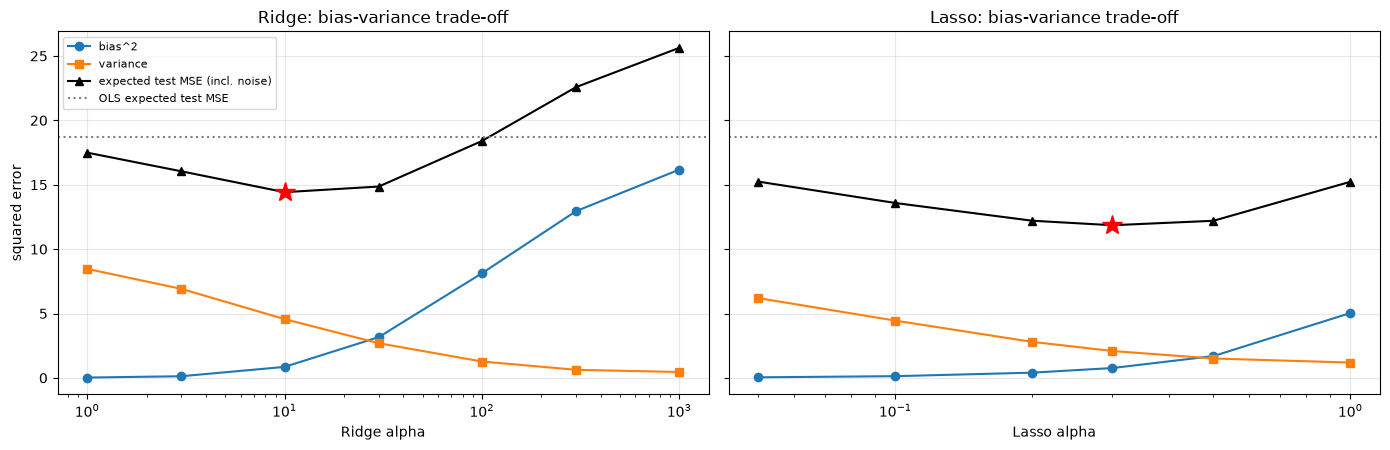

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), sharey=True)
ols_total = bv.loc[bv.model == "OLS", "expected test MSE"].iloc[0]
for ax, name in zip(axes, ["Ridge", "Lasso"]):
    d = bv[bv.model == name]
    ax.plot(d.alpha, d["bias^2"], "o-", label="bias^2"); ax.plot(d.alpha, d["variance"], "s-", label="variance")
    ax.plot(d.alpha, d["expected test MSE"], "^-k", label="expected test MSE (incl. noise)")
    ax.axhline(ols_total, color="grey", ls=":", label="OLS expected test MSE")
    best = d.loc[d["expected test MSE"].idxmin()]
    ax.plot(best.alpha, best["expected test MSE"], "r*", ms=15)
    ax.set_xscale("log"); ax.set_xlabel(f"{name} alpha"); ax.set_title(f"{name}: bias-variance trade-off"); ax.grid(alpha=0.3)
axes[0].set_ylabel("squared error"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()

The measurement matches the theory and the book's statement:

* **Bias² rises and variance falls monotonically** as `alpha` grows, for both Ridge (variance 8.46 → 0.46, bias² 0.03 → 16.17) and Lasso (variance 6.20 → 1.19, bias² 0.05 → 5.04). OLS has the lowest bias (0.02) but the highest variance (9.67).
* The **minimum of the total** is at a moderate `alpha`: Ridge at `alpha=10` (bias² 0.85, variance 4.57, total 14.42) and Lasso at `alpha=0.3` (bias² 0.77, variance 2.09, total 11.86), against 18.69 for OLS. Both are "a small increase in bias for a large cut in variance": for Ridge the bias² grows by 0.83 while the variance falls by 5.1; for Lasso the numbers are +0.75 and −7.6.
* Measured as error **above the irreducible noise** (9): OLS 9.7, best Ridge 5.4 (**44 % less**), best Lasso 2.9 (**70 % less**). Lasso wins by a wide margin because the truth is sparse (5 of 30 coefficients are non-zero).
* **Too much regularization is as bad as too little**: Ridge with `alpha=1000` has a total error of 25.63, *worse than OLS*, because the bias² (16.17) now dominates.

### 4.3 Choosing `alpha`: the validation curve

Since `alpha` is a hyperparameter, we pick it by cross-validation (Chapter 1, 4). The curve below is on the collinear dataset of Section 2.7. Both axes are logarithmic. The **training** error always rises with `alpha` (the model fits the training data less closely); the **validation** error first falls (less over-fitting) and then rises (under-fitting): a U shape with its minimum at the best `alpha`.

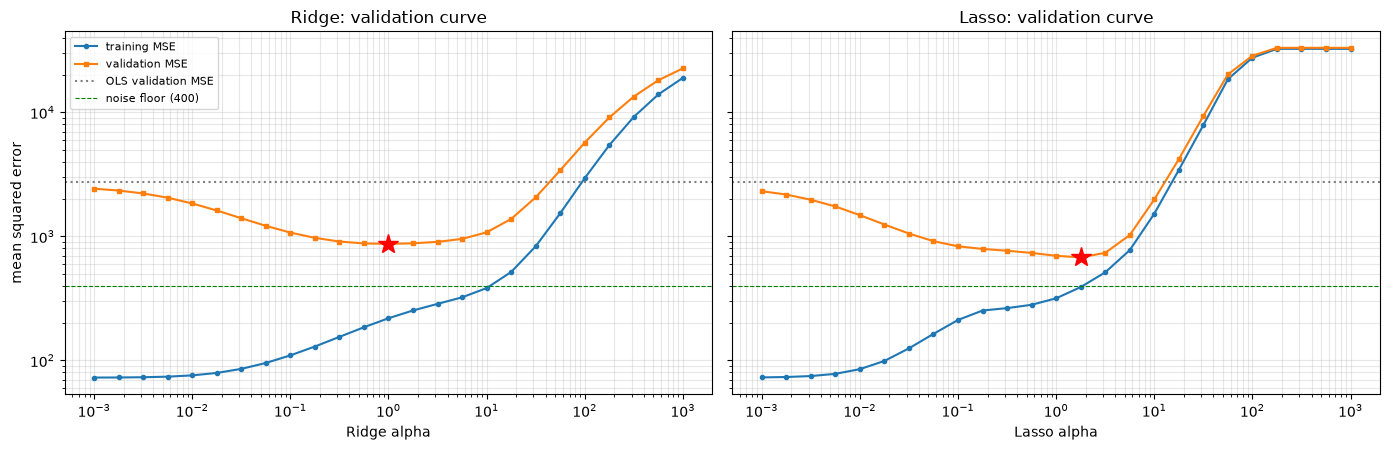

{'Ridge': 'alpha = 1, validation MSE = 869', 'Lasso': 'alpha = 1.78, validation MSE = 677'}


In [30]:
alphas_vc = np.logspace(-3, 3, 25)
cv_vc = RepeatedKFold(n_splits=5, n_repeats=3, random_state=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), sharey=True)
vc_best = {}
for ax, (name, est) in zip(axes, [("Ridge", Ridge()), ("Lasso", Lasso(max_iter=50000))]):
    pipe = make_pipeline(StandardScaler(), est)
    tr, va = validation_curve(pipe, X_fix, y_fix, param_name=f"{name.lower()}__alpha", param_range=alphas_vc,
                              cv=cv_vc, scoring="neg_mean_squared_error")
    tr, va = -tr.mean(axis=1), -va.mean(axis=1)
    k = va.argmin(); vc_best[name] = (alphas_vc[k], va[k])
    ax.loglog(alphas_vc, tr, "o-", ms=3, label="training MSE"); ax.loglog(alphas_vc, va, "s-", ms=3, label="validation MSE")
    ax.axhline(fix_table.loc["OLS", "mean test MSE"], color="grey", ls=":", label="OLS validation MSE")
    ax.axhline(400, color="green", ls="--", lw=0.8, label="noise floor (400)")
    ax.plot(alphas_vc[k], va[k], "r*", ms=15); ax.set_xlabel(f"{name} alpha"); ax.set_title(f"{name}: validation curve"); ax.grid(alpha=0.3, which="both")
axes[0].set_ylabel("mean squared error"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.show()
print({k: f"alpha = {a:.3g}, validation MSE = {m:,.0f}" for k, (a, m) in vc_best.items()})

Both curves show the expected shape: the **training** error rises steadily with `alpha`, while the **validation** error falls to a minimum and then rises again: at `alpha` = 1 for Ridge (validation MSE 869) and `alpha` ≈ 1.8 for Lasso (677). Both are far below unregularized OLS (2 761) and the Lasso gets within a factor of 1.7 of the noise floor (400).

A caution: the minimum of a validation curve is slightly optimistic, because the same folds are used to choose *and* to score `alpha`. Section 2.7's nested estimate for RidgeCV was 939 (different fold sets, so only roughly comparable) against 869 here, while for Lasso it was 680 against 677.

### 4.4 There's more: Bayesian and grouped penalties

The book closes the recipe with two pointers: **Bayesian regression** and **group Lasso**.

* **Bayesian view of regularization.** Ridge is the *maximum a posteriori* (MAP) estimate when each coefficient has a Gaussian prior $\beta_j\sim\mathcal N(0,\tau^2)$, with $\alpha=\sigma^2/\tau^2$ (noise variance divided by prior variance). Lasso corresponds to a Laplace (double-exponential) prior, whose sharp peak at 0 explains why it produces exact zeros. `BayesianRidge` goes one step further: instead of cross-validating $\alpha$ it **estimates the noise precision and the prior precision from the data**.
* **Group Lasso** penalises whole *groups* of coefficients (e.g. all dummy columns of one categorical variable) so they enter or leave the model together. It is not in scikit-learn (separate packages such as `skglm` or `group-lasso` provide it).

A short `BayesianRidge` check on the collinear dataset:

In [31]:
bayes = make_pipeline(StandardScaler(), BayesianRidge())
res = cross_validate(bayes, X_fix, y_fix, cv=cv_fix, scoring=("r2", "neg_mean_squared_error"))
bayes.fit(X_fix, y_fix)
br = bayes[-1]

print(f"BayesianRidge   : CV R^2 = {res['test_r2'].mean():.3f}, test MSE = {-res['test_neg_mean_squared_error'].mean():,.0f}")
print(f"RidgeCV (above) : CV R^2 = {fix_table.loc['RidgeCV', 'mean R^2']:.3f}, test MSE = {fix_table.loc['RidgeCV', 'mean test MSE']:,.0f}")
print()
print(f"estimated noise variance 1/alpha_      : {1 / br.alpha_:,.0f}   (true value 400)")
print(f"implied ridge penalty  lambda_/alpha_  : {br.lambda_ / br.alpha_:.2f}   (RidgeCV chose {fitted['RidgeCV'][-1].alpha_:.2f})")

BayesianRidge   : CV R^2 = 0.970, test MSE = 898
RidgeCV (above) : CV R^2 = 0.969, test MSE = 939

estimated noise variance 1/alpha_      : 459   (true value 400)
implied ridge penalty  lambda_/alpha_  : 1.43   (RidgeCV chose 1.13)


`BayesianRidge` achieves the same accuracy as the cross-validated Ridge (test MSE 898 vs 939; $R^2$ 0.970 vs 0.969) **without a search over `alpha`**. It also gives interpretable by-products: its estimate of the noise variance is **459**, 15 % above the true 400, and the ridge penalty it implies (1.43) is within a factor of 1.3 of the one cross-validation chose (1.13). When a single, well-calibrated linear model is needed quickly, this is a useful alternative to `RidgeCV`.

## 5. Regression and regularization: polynomial regression and splines

So far every model was linear in the *original* features. To model curves we keep the *linear model* but feed it **transformed features**. The book shows two ways.

### 5.1 The book's non-linear dataset

One feature $x\in[-50,50]$ and a target that is a line plus a sine wave plus noise: $y=2x+27\sin(x/8)+\varepsilon$, $\varepsilon\sim\mathcal N(0,4^2)$. The noise variance is therefore $4^2=16$, which is the best MSE any model can hope to reach.

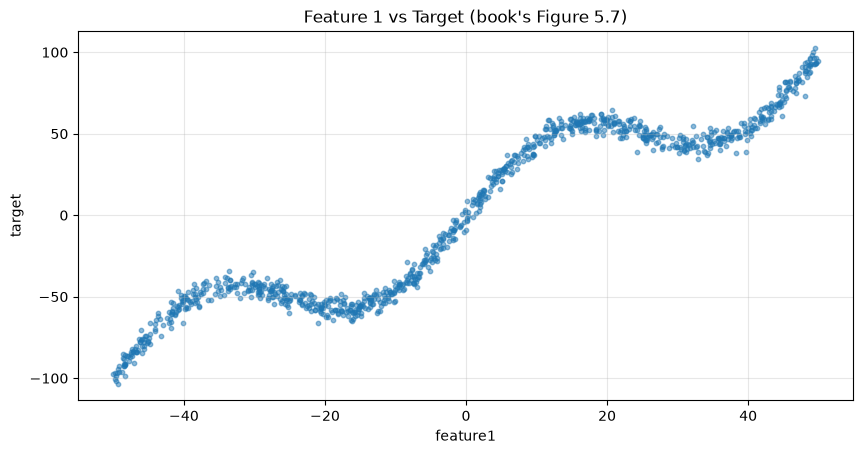

noise variance used to generate the data (the nominal best MSE): 16
noise variance actually realised in these 1000 draws          : 14.82
variance of the signal 2x + 27 sin(x/8)                       : 2873


In [32]:
np.random.seed(123)
n_samples = 1000
X_nl = np.random.uniform(-50, 50, (n_samples, 1))
y_nl = 2 * X_nl[:, 0] + 27 * np.sin(X_nl[:, 0] / 8) + np.random.normal(0, 4, n_samples)
data = pd.DataFrame({"feature1": X_nl[:, 0], "target": y_nl})

plt.figure(figsize=(10, 4.8))
plt.scatter(data["feature1"], data["target"], s=10, alpha=0.5)
plt.title("Feature 1 vs Target (book's Figure 5.7)"); plt.xlabel("feature1"); plt.ylabel("target"); plt.grid(alpha=0.3); plt.show()
realised_noise = y_nl - (2 * X_nl[:, 0] + 27 * np.sin(X_nl[:, 0] / 8))
print("noise variance used to generate the data (the nominal best MSE): 16")
print("noise variance actually realised in these 1000 draws          : %.2f" % realised_noise.var())
print("variance of the signal 2x + 27 sin(x/8)                       : %.0f" % np.var(2 * X_nl[:, 0] + 27 * np.sin(X_nl[:, 0] / 8)))

### 5.2 Polynomial regression

`PolynomialFeatures(degree=d)` replaces $x$ by $(1,x,x^2,\dots,x^d)$ and then OLS fits

$$y=\beta_0+\beta_1x+\beta_2x^2+\dots+\beta_dx^d+\varepsilon .$$

The model is still *linear in the coefficients*, so everything we know about OLS (and Ridge/Lasso) still applies; only the features are curved. The book tries degrees 1 to 5 and reports MSE and $R^2$ on a held-out split.

In [33]:
degrees = [1, 2, 3, 4, 5]
results = []
for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(data[["feature1"]])
    Xp_tr, Xp_te, yp_tr, yp_te = train_test_split(X_poly, data["target"], test_size=0.2, random_state=123)
    poly_model = LinearRegression().fit(Xp_tr, yp_tr)
    y_hat = poly_model.predict(Xp_te)
    results.append({"Degree": degree, "MSE": mean_squared_error(yp_te, y_hat), "R2": r2_score(yp_te, y_hat),
                    "condition number of X": np.linalg.cond(Xp_tr)})
results_df = pd.DataFrame(results)
print("Model Performance Metrics:")
results_df.style.format({"MSE": "{:.2f}", "R2": "{:.4f}", "condition number of X": "{:.2e}"}).hide(axis="index")

Model Performance Metrics:


Degree,MSE,R2,condition number of X
1,317.01,0.8911,2.84e+01
2,316.82,0.8912,1.62e+03
3,268.48,0.9078,6.88e+04
4,268.23,0.9079,3.82e+06
5,811.07,0.7215,1.74e+08


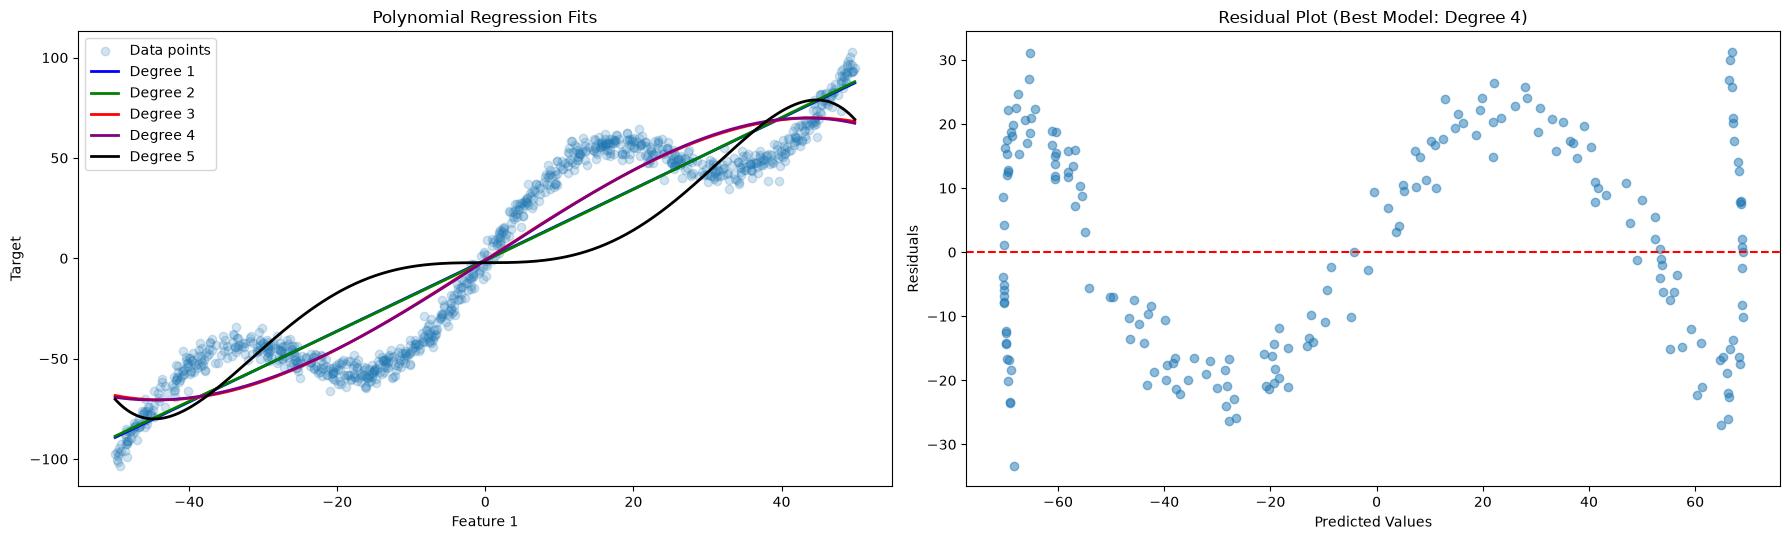

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5.5))
ax1.scatter(data["feature1"], data["target"], alpha=0.2, label="Data points")
X_curve = np.linspace(data["feature1"].min(), data["feature1"].max(), 1000).reshape(-1, 1)
for degree, color in zip(degrees, ["blue", "green", "red", "purple", "black"]):
    poly = PolynomialFeatures(degree=degree)
    m = LinearRegression().fit(poly.fit_transform(data[["feature1"]]), data["target"])
    ax1.plot(X_curve, m.predict(poly.transform(X_curve)), label=f"Degree {degree}", color=color, lw=2)
ax1.set_xlabel("Feature 1"); ax1.set_ylabel("Target"); ax1.set_title("Polynomial Regression Fits"); ax1.legend(loc="upper left")

best_degree = int(results_df.loc[results_df["R2"].idxmax(), "Degree"])
best_poly = PolynomialFeatures(degree=best_degree)
Xb = best_poly.fit_transform(data[["feature1"]])
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb, data["target"], test_size=0.2, random_state=123)
best_model = LinearRegression().fit(Xb_tr, yb_tr)
pred_b = best_model.predict(Xb_te)
ax2.scatter(pred_b, yb_te - pred_b, alpha=0.5); ax2.axhline(0, color="r", ls="--")
ax2.set_xlabel("Predicted Values"); ax2.set_ylabel("Residuals"); ax2.set_title(f"Residual Plot (Best Model: Degree {best_degree})")
plt.tight_layout(); plt.show()

What the table and the plots reveal:

* **Even degrees add nothing.** Degree 2 ≈ degree 1 (MSE 316.8 vs 317.0) and degree 4 ≈ degree 3 (268.2 vs 268.5). The target $2x+27\sin(x/8)$ is an **odd function** (symmetric about the origin), and even powers of $x$ are even functions, so they cannot help; only the odd powers $x, x^3, x^5,\dots$ do.
* The book calls degree 5 the "best" model, but only because it is the **largest degree tried**. Its MSE of 48.3 is about 3 times the noise level (16 nominal, 14.8 actually realised in these 1 000 draws), so it is far from the best achievable. $R^2=0.983$ looks excellent and hides that gap, because the target has a large variance (≈ 2 900) that dominates the $R^2$ denominator.
* The **condition number** of the design matrix grows from 28 to **1.7 × 10⁸** with the degree: raw powers $x^k$ of a variable that goes up to 50 are nearly collinear and numerically fragile. That is why Section 5.3 standardises $x$ first.

### 5.3 Beyond degree 5: a fair comparison with cross-validation

The book stops at degree 5 and picks it by the highest $R^2$ on one split. We extend the range, scale $x$ before building the powers (to tame the huge condition numbers above) and use **repeated cross-validation**:

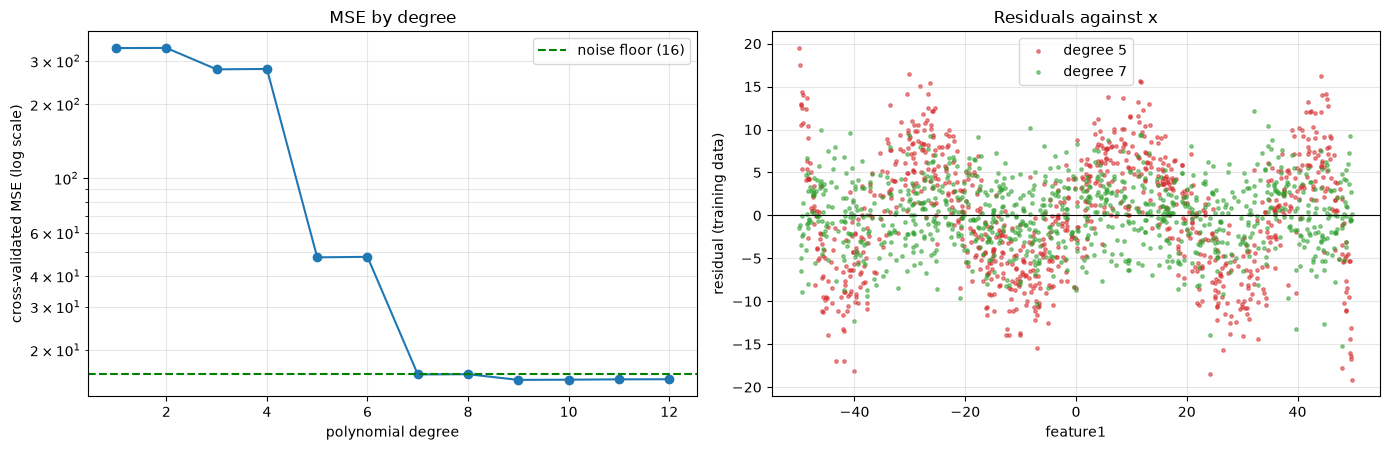

,CV MSE,std over folds
1,337.95,21.24
2,338.44,21.32
3,276.95,12.79
4,277.94,13.04
5,47.59,2.93
6,47.80,2.97
7,15.89,1.40
8,15.92,1.43
9,15.09,1.31
10,15.12,1.30


In [35]:
cv_poly = RepeatedKFold(n_splits=5, n_repeats=5, random_state=0)
deg_range = list(range(1, 13))
cv_mse = {}
for d in deg_range:
    pipe = make_pipeline(StandardScaler(), PolynomialFeatures(d, include_bias=False), LinearRegression())
    s = -cross_val_score(pipe, X_nl, y_nl, cv=cv_poly, scoring="neg_mean_squared_error")
    cv_mse[d] = (s.mean(), s.std())

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
axes[0].semilogy(deg_range, [cv_mse[d][0] for d in deg_range], "o-")
axes[0].axhline(16, color="green", ls="--", label="noise floor (16)"); axes[0].set_xlabel("polynomial degree"); axes[0].set_ylabel("cross-validated MSE (log scale)")
axes[0].set_title("MSE by degree"); axes[0].legend(); axes[0].grid(alpha=0.3, which="both")

# residuals against x: degree 5 (the book's 'best') vs degree 7
for d, c in [(5, "tab:red"), (7, "tab:green")]:
    pipe = make_pipeline(StandardScaler(), PolynomialFeatures(d, include_bias=False), LinearRegression()).fit(X_nl, y_nl)
    order = np.argsort(X_nl[:, 0])
    axes[1].scatter(X_nl[order, 0], (y_nl - pipe.predict(X_nl))[order], s=6, alpha=0.5, color=c, label=f"degree {d}")
axes[1].axhline(0, color="k", lw=0.8); axes[1].set_xlabel("feature1"); axes[1].set_ylabel("residual (training data)"); axes[1].set_title("Residuals against x"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

pd.DataFrame({d: {"CV MSE": cv_mse[d][0], "std over folds": cv_mse[d][1]} for d in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12]}).T.round(2)

With cross-validation, the picture is different from the book's:

* **Degree 5 is not the best.** Its CV MSE is **47.6**; degree 7 reaches **15.9**, three times lower, and from degree 7 on the curve is flat (15.1-15.9 for degrees 7-12), within about 6 % of the realised noise level 14.8. The differences among degrees 7-12 (at most 0.8) are smaller than the fold-to-fold standard deviation (≈ 1.3), so **any degree ≥ 7 is equally good**; degree 7 is the simplest.
* The residuals against $x$ (right panel) show the difference: for **degree 5** (red) they form a systematic wave across the range, so the model is still missing structure; for **degree 7** (green) they look like featureless noise around 0.
* Note that with 1 000 samples and a scaled $x$, even degree 12 does not over-fit (CV MSE 15.19). High degrees become dangerous with *few* samples, as the exercises in Section 6 show.

### 5.4 Spline regression

A polynomial is **global**: one formula for the whole range, so a local wiggle at one end can drag the curve at the other. A **spline** is **piecewise**: the range is cut at **knots** and a low-degree polynomial (here cubic) is fitted on each piece, with the pieces joined smoothly. `SplineTransformer` builds the **B-spline basis**: a set of smooth "bump" functions, each non-zero only over a few neighbouring pieces. A linear regression on that basis gives the spline. More knots mean more flexibility.

> **📝 Note.** The book calls this *spline interpolation*, a curve that **passes through** all the data points. `SplineTransformer` + `LinearRegression` does not interpolate: it is a **least-squares regression spline**, a smooth fit that is *not* forced through the points, which is what we want with noisy data.

The book fits 3, 5 and 7 knots with cubic splines (`degree=3`):

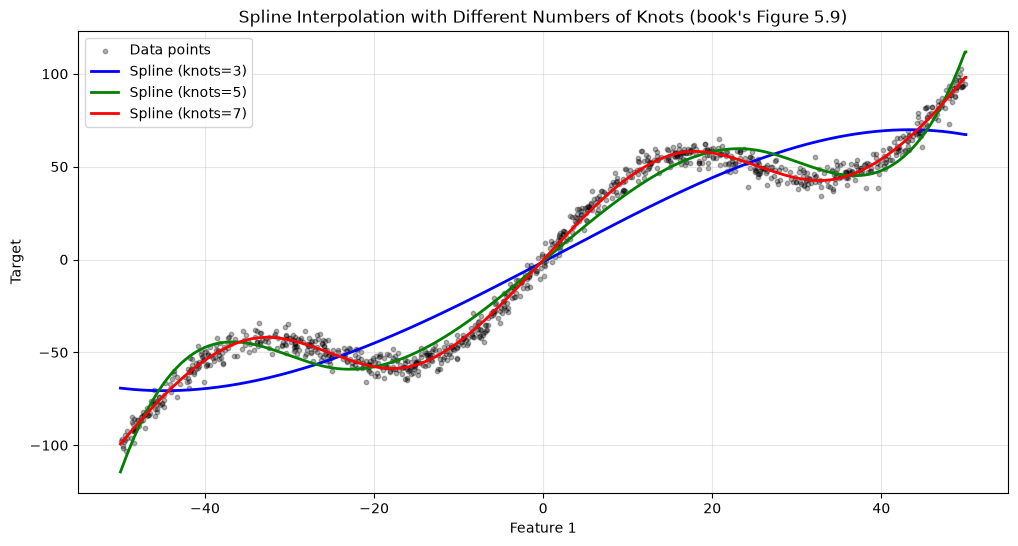

metrics computed on the TRAINING data, as in the book (its Figure 5.10 shows 274.19, 55.36, 15.50):


Number of Knots,MSE,R-squared
3,274.27,0.9047
5,55.35,0.9808
7,15.50,0.9946


In [36]:
n_knots_list = [3, 5, 7]
x_plot = np.linspace(-50, 50, 1000).reshape(-1, 1)
spline_rows = []

plt.figure(figsize=(12, 6))
plt.scatter(X_nl, y_nl, color="black", alpha=0.3, s=10, label="Data points")
for n_knot, color in zip(n_knots_list, ["blue", "green", "red"]):
    spline_model = make_pipeline(SplineTransformer(n_knots=n_knot, degree=3), LinearRegression())
    spline_model.fit(X_nl, y_nl)
    y_train_pred = spline_model.predict(X_nl)
    spline_rows.append({"Number of Knots": n_knot, "MSE": mean_squared_error(y_nl, y_train_pred), "R-squared": r2_score(y_nl, y_train_pred)})
    plt.plot(x_plot, spline_model.predict(x_plot), color=color, lw=2, label=f"Spline (knots={n_knot})")
plt.xlabel("Feature 1"); plt.ylabel("Target"); plt.title("Spline Interpolation with Different Numbers of Knots (book's Figure 5.9)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

print("metrics computed on the TRAINING data, as in the book (its Figure 5.10 shows 274.19, 55.36, 15.50):")
pd.DataFrame(spline_rows).style.format({"MSE": "{:.2f}", "R-squared": "{:.4f}"}).hide(axis="index")

The reproduction matches the book's Figure 5.10 (our 274.27, 55.35 and 15.50 against the book's 274.19, 55.36 and 15.50), and the interpretation is the same one as for polynomials:

* **3 knots** are too few (MSE 274, about the same as a cubic polynomial); **5 knots** capture most of the shape (55.4); **7 knots** reach the noise level (15.5 against the realised 14.8).
* A cubic spline with 7 knots uses 9 basis functions, similar in size to a degree-7 polynomial (8 coefficients) that scored about the same in Section 5.3. In the range where the data live, the two approaches are equally good; they differ in what happens at the edges and outside the range (Section 5.6).
* The book's metrics are computed on the **training** data, which is why it can state that "more knots always lowers the MSE". The next cell shows this is true for training error only.

### 5.5 Knots and honesty: training error vs. cross-validated error

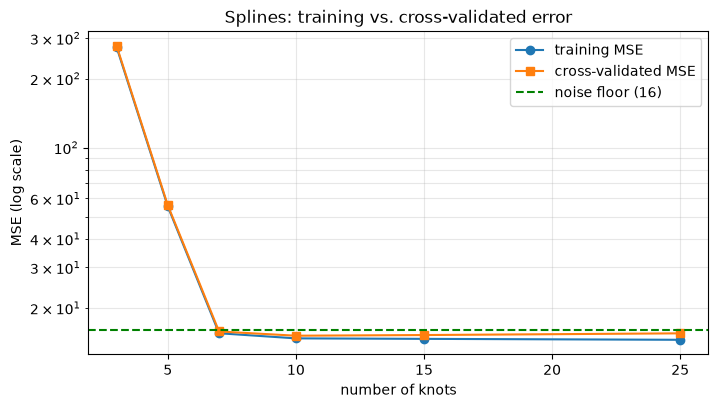

,training MSE,cross-validated MSE,std over folds
n_knots,,,
3,274.27,277.81,12.98
5,55.35,55.99,2.72
7,15.50,15.78,1.49
10,14.73,15.12,1.29
15,14.65,15.22,1.32
25,14.52,15.49,1.35


In [37]:
knots_range = [3, 5, 7, 10, 15, 25]
rows = {}
for k in knots_range:
    sp = make_pipeline(SplineTransformer(n_knots=k, degree=3), LinearRegression())
    train_mse = mean_squared_error(y_nl, sp.fit(X_nl, y_nl).predict(X_nl))
    s = -cross_val_score(sp, X_nl, y_nl, cv=cv_poly, scoring="neg_mean_squared_error")
    rows[k] = {"training MSE": train_mse, "cross-validated MSE": s.mean(), "std over folds": s.std()}
spl = pd.DataFrame(rows).T.rename_axis("n_knots")

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(spl.index, spl["training MSE"], "o-", label="training MSE"); ax.plot(spl.index, spl["cross-validated MSE"], "s-", label="cross-validated MSE")
ax.axhline(16, color="green", ls="--", label="noise floor (16)"); ax.set_yscale("log"); ax.set_xlabel("number of knots"); ax.set_ylabel("MSE (log scale)")
ax.set_title("Splines: training vs. cross-validated error"); ax.legend(); ax.grid(alpha=0.3, which="both"); plt.show()
spl.round(2)

Training MSE keeps falling slowly as knots are added (15.50 → 14.52), but the **cross-validated MSE is lowest at 10 knots (15.12)** and creeps upwards afterwards (15.22 at 15 knots, 15.49 at 25 knots). The gap between training and CV error widens with flexibility (0.3 at 7 knots, 1.0 at 25): a mild sign of over-fitting. With 1 000 points the harm is small, and the differences between 7 and 25 knots are smaller than the fold-to-fold spread (≈ 1.3-1.5), so anything from about 7 to 15 knots is adequate. The book's conclusion ("more knots, lower MSE, better fit") is true only for the training error.

### 5.6 Extrapolation: where polynomials and splines part ways

All the fits above are judged *inside* the range $[-50, 50]$. What happens *outside* it? We predict at $x=\pm60,\pm70$, where the truth is $2x+27\sin(x/8)$.

In [38]:
poly5 = make_pipeline(StandardScaler(), PolynomialFeatures(5, include_bias=False), LinearRegression()).fit(X_nl, y_nl)
poly7 = make_pipeline(StandardScaler(), PolynomialFeatures(7, include_bias=False), LinearRegression()).fit(X_nl, y_nl)
spline_const = make_pipeline(SplineTransformer(n_knots=7, degree=3), LinearRegression()).fit(X_nl, y_nl)
spline_lin = make_pipeline(SplineTransformer(n_knots=7, degree=3, extrapolation="linear"), LinearRegression()).fit(X_nl, y_nl)

x_out = np.array([[-70.0], [-60.0], [60.0], [70.0]])
truth = 2 * x_out[:, 0] + 27 * np.sin(x_out[:, 0] / 8)
pd.DataFrame({"truth": truth, "polynomial deg 5": poly5.predict(x_out), "polynomial deg 7": poly7.predict(x_out),
              "spline (default: constant)": spline_const.predict(x_out), "spline (extrapolation='linear')": spline_lin.predict(x_out)},
             index=[f"x = {int(v)}" for v in x_out[:, 0]]).round(0)

,truth,polynomial deg 5,polynomial deg 7,spline (default: constant),spline (extrapolation='linear')
x = -70,-157.0,-1079.0,1115.0,-99.0,-209.0
x = -60,-145.0,-392.0,37.0,-99.0,-154.0
x = 60,145.0,384.0,-39.0,98.0,155.0
x = 70,157.0,1058.0,-1113.0,98.0,211.0


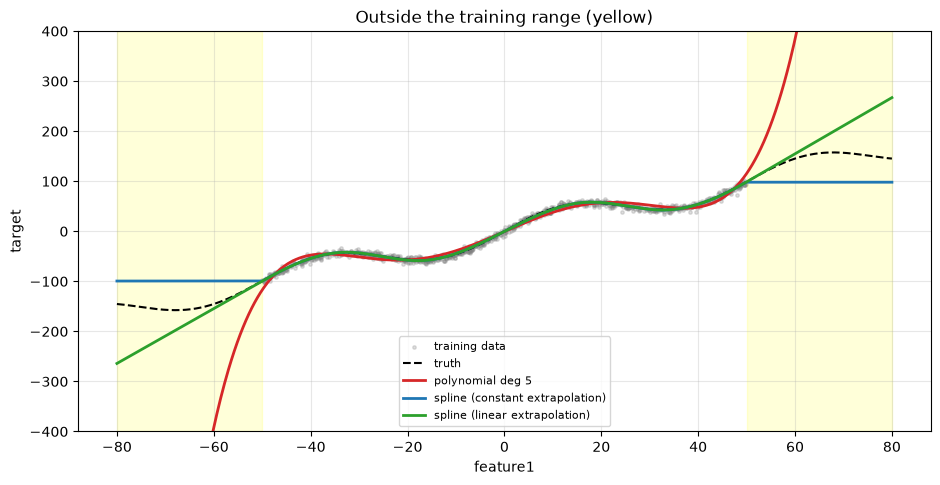

In [39]:
xw = np.linspace(-80, 80, 800).reshape(-1, 1)
plt.figure(figsize=(11, 5.2))
plt.scatter(X_nl, y_nl, s=6, alpha=0.25, color="grey", label="training data")
plt.plot(xw, 2 * xw[:, 0] + 27 * np.sin(xw[:, 0] / 8), "k--", lw=1.5, label="truth")
for m, lab, c in [(poly5, "polynomial deg 5", "tab:red"), (spline_const, "spline (constant extrapolation)", "tab:blue"), (spline_lin, "spline (linear extrapolation)", "tab:green")]:
    plt.plot(xw, m.predict(xw), color=c, lw=2, label=lab)
plt.axvspan(-80, -50, color="yellow", alpha=0.15); plt.axvspan(50, 80, color="yellow", alpha=0.15)
plt.ylim(-400, 400); plt.xlabel("feature1"); plt.ylabel("target"); plt.title("Outside the training range (yellow)"); plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.show()

Outside the training range the methods diverge sharply:

| x | truth | polynomial deg 5 | polynomial deg 7 | spline (constant) | spline (linear) |
|---|---|---|---|---|---|
| −70 | −157 | −1 079 | **+1 115** | −99 | −209 |
| −60 | −145 | −392 | +37 | −99 | −154 |
| 60 | 145 | 384 | −39 | 98 | 155 |
| 70 | 157 | 1 058 | **−1 113** | 98 | 211 |

* The **polynomials explode**: at ±70 the degree-5 prediction is about 7 times the truth, and the degree-7 polynomial, which fits *better* inside the data, is off by about 7 times *and has the wrong sign*. High-order powers dominate as soon as $|x|$ leaves the data range.
* The **spline** stays bounded by construction: scikit-learn's default continues the end value as a constant (−99 / +98, which under-estimates by about 37 % at ±70), and `extrapolation="linear"` continues the end slope (within 7 % at ±60, 34 % too large at ±70).
* No method "knows" the sine wave beyond the data: extrapolation needs knowledge about the process, not flexibility. The practical advice is to avoid high-degree polynomials for prediction outside the observed range, and to check that new inputs fall inside it.

### 5.7 Regularization rescues a too-flexible spline

Flexible bases are exactly where Ridge earns its keep. Take only **60** training points and compare spline regressions with 7, 25 and 40 knots, unpenalised (`alpha` $\approx0$) and with a small Ridge penalty.

In [40]:
r_small = np.random.RandomState(123)
X_s = r_small.uniform(-50, 50, (60, 1))
y_s = 2 * X_s[:, 0] + 27 * np.sin(X_s[:, 0] / 8) + r_small.normal(0, 4, 60)

cv_s = RepeatedKFold(n_splits=5, n_repeats=10, random_state=0)
rows = {}
for k in [7, 10, 25, 40]:
    rows[f"{k} knots"] = {f"Ridge alpha={a:g}": -cross_val_score(make_pipeline(SplineTransformer(n_knots=k, degree=3), Ridge(alpha=a)),
                                                               X_s, y_s, cv=cv_s, scoring="neg_mean_squared_error").mean()
                         for a in [1e-8, 0.001, 0.01, 0.1, 1]}
pd.DataFrame(rows).T.style.format("{:,.1f}")

,Ridge alpha=1e-08,Ridge alpha=0.001,Ridge alpha=0.01,Ridge alpha=0.1,Ridge alpha=1
7 knots,34.4,35.5,42.9,59.1,211.2
10 knots,42.5,40.3,41.8,51.9,240.8
25 knots,"1,132,925.4",95.5,69.8,102.6,541.9
40 knots,"150,763.6",231.6,195.2,248.4,808.2


With only 60 points (48 per fold):

* The spline with **25 knots** (27 basis functions for 48 training rows) and no penalty is catastrophic: CV MSE ≈ **1.1 million**. Some folds leave stretches of the range without data, and the unconstrained coefficients explode. A *tiny* penalty (`alpha=0.01`) brings it to **69.8**, an improvement of more than 16 000 times. The 40-knot spline shows the same pattern (150 764 → 195 at `alpha=0.01`).
* Regularization **rescues** a too-flexible model, but it does **not beat the right model size**: the plain 7-knot spline without any penalty (34.4) is better than every penalised 25- or 40-knot version. Choosing the right complexity and regularizing are complementary, not interchangeable.
* Larger penalties hurt every model (`alpha=1`: 211 to 808): the same U shape as in Section 4.3.
* The 60-point MSEs (best 34.4) are also well above the 1 000-point ones (15.5): with little data, even a good model pays an estimation cost.

## 6. Practical exercises with regularization techniques

The book gives only the *steps* of three exercises (load libraries → generate a noisy synthetic dataset → split → fit → predict → metrics → plot with *sorted* $x$ values for a smooth line) and leaves the implementation to the reader, one regularizer per exercise, with `random_state=123` / `np.random.seed(123)`.

To make the three exercises comparable, **one shared dataset** is used. It is chosen so that regularization has something to do: 100 noisy samples from a smooth curve, $y=\sin x+0.3x+\varepsilon$ ($\varepsilon\sim\mathcal N(0,0.35^2)$), modelled with a **degree-12 polynomial** (12 correlated, wildly scaled features, far more flexible than the 80 training points justify).

*Pipeline for every exercise:* scale $x$ → degree-12 `PolynomialFeatures` → scale the 12 powers → regularized linear model. Scaling the powers matters (Section 2.6): otherwise $x^{12}$ would be penalised thousands of times less than $x$. Since the true curve is known, we can report not only the usual test error but also the error against the **true curve**, which measures how close each fit is to the underlying truth rather than to the noisy test points.

In [41]:
rng = np.random.RandomState(123)
x_all = rng.uniform(-3, 3, 100)
f_true = lambda t: np.sin(t) + 0.3 * t
y_all = f_true(x_all) + rng.normal(0, 0.35, 100)

X_ex, y_ex = x_all.reshape(-1, 1), y_all
Xex_tr, Xex_te, yex_tr, yex_te = train_test_split(X_ex, y_ex, test_size=0.2, random_state=123)
x_dense = np.linspace(-3, 3, 400).reshape(-1, 1)           # sorted x values for smooth line plots

def poly_pipeline(estimator, degree=12):
    return make_pipeline(StandardScaler(), PolynomialFeatures(degree, include_bias=False), StandardScaler(), estimator)

def evaluate(model, name):
    p_tr, p_te = model.predict(Xex_tr), model.predict(Xex_te)
    coefs = model[-1].coef_
    return {"model": name,
            "train MSE": mean_squared_error(yex_tr, p_tr), "test MSE": mean_squared_error(yex_te, p_te),
            "test R^2": r2_score(yex_te, p_te),
            "MSE vs TRUE curve": mean_squared_error(f_true(x_dense[:, 0]), model.predict(x_dense)),
            "largest |coef|": np.abs(coefs).max(), "non-zero coef (of 12)": int((np.abs(coefs) > 1e-8).sum())}

print("train:", Xex_tr.shape, "| test:", Xex_te.shape, "| noise variance (best possible MSE vs noisy y): 0.35^2 = %.3f" % 0.35**2)

train: (80, 1) | test: (20, 1) | noise variance (best possible MSE vs noisy y): 0.35^2 = 0.122


### 6.0 Baseline: the unregularized degree-12 fit

Before regularizing, we need to see the problem:

In [42]:
ols_ex = poly_pipeline(LinearRegression()).fit(Xex_tr, yex_tr)
rows_ex = [evaluate(ols_ex, "OLS (degree 12)")]
pd.DataFrame(rows_ex).set_index("model").round(3)

,train MSE,test MSE,test R^2,MSE vs TRUE curve,largest |coef|,non-zero coef (of 12)
model,,,,,,
OLS (degree 12),0.103,0.159,0.899,0.011,40.925,12


### 6.1 Exercise 1: Ridge regression

Ridge Regression (alpha=1.0)
  Mean Squared Error (test): 0.1798
  R-squared (test)         : 0.8863


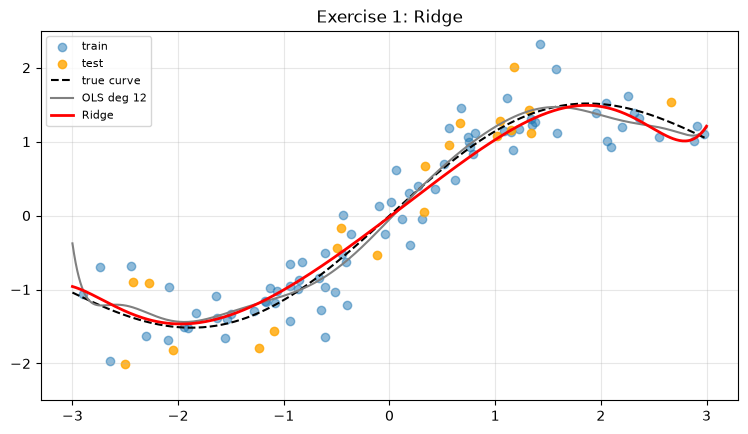

In [43]:
ridge_ex = poly_pipeline(Ridge(alpha=1.0)).fit(Xex_tr, yex_tr)
y_pred_ridge_ex = ridge_ex.predict(Xex_te)

print("Ridge Regression (alpha=1.0)")
print(f"  Mean Squared Error (test): {mean_squared_error(yex_te, y_pred_ridge_ex):.4f}")
print(f"  R-squared (test)         : {r2_score(yex_te, y_pred_ridge_ex):.4f}")
rows_ex.append(evaluate(ridge_ex, "Ridge (alpha=1)"))

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.scatter(Xex_tr, yex_tr, alpha=0.5, label="train"); ax.scatter(Xex_te, yex_te, alpha=0.8, color="orange", label="test")
ax.plot(x_dense, f_true(x_dense[:, 0]), "k--", label="true curve"); ax.plot(x_dense, ols_ex.predict(x_dense), color="grey", label="OLS deg 12")
ax.plot(x_dense, ridge_ex.predict(x_dense), "r", lw=2, label="Ridge")
ax.set_ylim(-2.5, 2.5); ax.set_title("Exercise 1: Ridge"); ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.show()

### 6.2 Exercise 2: Lasso regression

Lasso Regression (alpha=0.03)
  Mean Squared Error (test): 0.2141
  R-squared (test)         : 0.8646


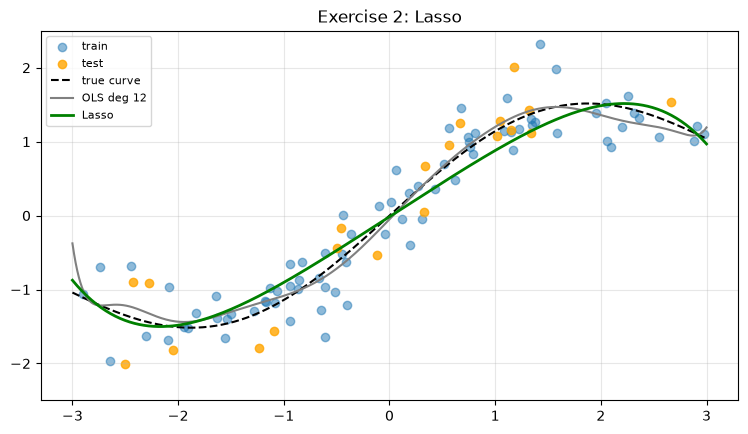

In [44]:
lasso_ex = poly_pipeline(Lasso(alpha=0.03, max_iter=100000)).fit(Xex_tr, yex_tr)
y_pred_lasso_ex = lasso_ex.predict(Xex_te)

print("Lasso Regression (alpha=0.03)")
print(f"  Mean Squared Error (test): {mean_squared_error(yex_te, y_pred_lasso_ex):.4f}")
print(f"  R-squared (test)         : {r2_score(yex_te, y_pred_lasso_ex):.4f}")
rows_ex.append(evaluate(lasso_ex, "Lasso (alpha=0.03)"))

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.scatter(Xex_tr, yex_tr, alpha=0.5, label="train"); ax.scatter(Xex_te, yex_te, alpha=0.8, color="orange", label="test")
ax.plot(x_dense, f_true(x_dense[:, 0]), "k--", label="true curve"); ax.plot(x_dense, ols_ex.predict(x_dense), color="grey", label="OLS deg 12")
ax.plot(x_dense, lasso_ex.predict(x_dense), "g", lw=2, label="Lasso")
ax.set_ylim(-2.5, 2.5); ax.set_title("Exercise 2: Lasso"); ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.show()

### 6.3 Exercise 3: ElasticNet regression

ElasticNet Regression (alpha=0.05, l1_ratio=0.5)
  Mean Squared Error (test): 0.2464
  R-squared (test)         : 0.8441


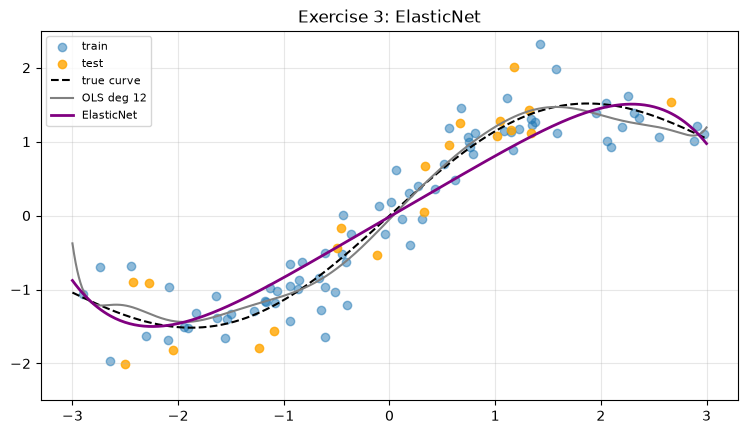

In [45]:
enet_ex = poly_pipeline(ElasticNet(alpha=0.05, l1_ratio=0.5, max_iter=100000)).fit(Xex_tr, yex_tr)
y_pred_enet_ex = enet_ex.predict(Xex_te)

print("ElasticNet Regression (alpha=0.05, l1_ratio=0.5)")
print(f"  Mean Squared Error (test): {mean_squared_error(yex_te, y_pred_enet_ex):.4f}")
print(f"  R-squared (test)         : {r2_score(yex_te, y_pred_enet_ex):.4f}")
rows_ex.append(evaluate(enet_ex, "ElasticNet (alpha=0.05, l1_ratio=0.5)"))

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.scatter(Xex_tr, yex_tr, alpha=0.5, label="train"); ax.scatter(Xex_te, yex_te, alpha=0.8, color="orange", label="test")
ax.plot(x_dense, f_true(x_dense[:, 0]), "k--", label="true curve"); ax.plot(x_dense, ols_ex.predict(x_dense), color="grey", label="OLS deg 12")
ax.plot(x_dense, enet_ex.predict(x_dense), "purple", lw=2, label="ElasticNet")
ax.set_ylim(-2.5, 2.5); ax.set_title("Exercise 3: ElasticNet"); ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.show()

### 6.4 Comparing the three (and not trusting a single split)

The three alphas above were picked by hand. Here is the comparison table, followed by the same four models evaluated with **repeated cross-validation**, where the regularized models choose their own `alpha` by an inner cross-validation (`RidgeCV`, `LassoCV`, `ElasticNetCV`), the fair way to compare them.

In [46]:
pd.DataFrame(rows_ex).set_index("model").round(3)

,train MSE,test MSE,test R^2,MSE vs TRUE curve,largest |coef|,non-zero coef (of 12)
model,,,,,,
OLS (degree 12),0.103,0.159,0.899,0.011,40.925,12
Ridge (alpha=1),0.116,0.180,0.886,0.009,1.606,12
Lasso (alpha=0.03),0.142,0.214,0.865,0.023,1.369,3
"ElasticNet (alpha=0.05, l1_ratio=0.5)",0.161,0.246,0.844,0.038,1.231,4


In [47]:
inner_ex = KFold(5, shuffle=True, random_state=1)
cv_ex = RepeatedKFold(n_splits=5, n_repeats=10, random_state=0)
tuned = {
    "OLS (degree 12)": poly_pipeline(LinearRegression()),
    "RidgeCV":         poly_pipeline(RidgeCV(alphas=np.logspace(-3, 3, 30), cv=inner_ex)),
    "LassoCV":         poly_pipeline(LassoCV(cv=inner_ex, max_iter=100000, random_state=0)),
    "ElasticNetCV":    poly_pipeline(ElasticNetCV(l1_ratio=[0.2, 0.5, 0.8, 1.0], cv=inner_ex, max_iter=100000, random_state=0)),
}
rows_cv = {}
for name, m in tuned.items():
    s = -cross_val_score(m, X_ex, y_ex, cv=cv_ex, scoring="neg_mean_squared_error")
    rows_cv[name] = {"CV test MSE": s.mean(), "std over folds": s.std()}
res_cv = pd.DataFrame(rows_cv).T
print("noise floor = 0.35^2 = 0.1225\n")
res_cv.round(4)

noise floor = 0.35^2 = 0.1225



,CV test MSE,std over folds
OLS (degree 12),0.7300,1.2617
RidgeCV,0.1563,0.0955
LassoCV,0.1382,0.0449
ElasticNetCV,0.1382,0.0449


In [48]:
# Where does unregularised OLS go wrong? Look at its MSE fold by fold, and at what the CV estimators chose.
fold_mse = {name: -cross_val_score(m, X_ex, y_ex, cv=cv_ex, scoring="neg_mean_squared_error") for name, m in tuned.items()}
ols_f, lasso_f = fold_mse["OLS (degree 12)"], fold_mse["LassoCV"]
print(f"OLS   : median fold MSE = {np.median(ols_f):.3f}, worst fold MSE = {ols_f.max():.2f}, folds with MSE > 1: {int((ols_f > 1).sum())} of {len(ols_f)}")
print(f"Lasso : median fold MSE = {np.median(lasso_f):.3f}, worst fold MSE = {lasso_f.max():.3f}")
print(f"LassoCV better than OLS in {100 * np.mean(lasso_f < ols_f):.0f}% of the {len(ols_f)} folds")

fit_all = {n_: m.fit(X_ex, y_ex) for n_, m in tuned.items() if n_ != "OLS (degree 12)"}
print()
print(f"alpha chosen by RidgeCV       : {fit_all['RidgeCV'][-1].alpha_:.3f}")
print(f"alpha chosen by LassoCV       : {fit_all['LassoCV'][-1].alpha_:.4f}  -> non-zero coefficients: {int((fit_all['LassoCV'][-1].coef_ != 0).sum())} of 12")
print(f"ElasticNetCV chose l1_ratio   : {fit_all['ElasticNetCV'][-1].l1_ratio_}, alpha = {fit_all['ElasticNetCV'][-1].alpha_:.4f}")

OLS   : median fold MSE = 0.190, worst fold MSE = 6.39, folds with MSE > 1: 10 of 50
Lasso : median fold MSE = 0.135, worst fold MSE = 0.261
LassoCV better than OLS in 94% of the 50 folds

alpha chosen by RidgeCV       : 2.043
alpha chosen by LassoCV       : 0.0103  -> non-zero coefficients: 3 of 12
ElasticNetCV chose l1_ratio   : 1.0, alpha = 0.0103


The two tables tell different stories, which is the real lesson of the exercises.

**On the single 80/20 split** (20 test points), plain OLS looks perfectly acceptable: test MSE **0.159**, against Ridge 0.180, Lasso 0.214 and ElasticNet 0.246. The hand-picked `alpha` values were too strong for Lasso (`alpha=0.03`) and ElasticNet (`alpha=0.05`): they keep only **3 and 4 of the 12** polynomial terms, too few to follow the curve. Yet the regularizers did what they are for in one respect: the largest coefficient falls from **40.9** (OLS) to **1.6** (Ridge), 1.4 (Lasso) and 1.2 (ElasticNet), and Ridge is as close to the *true curve* as OLS (0.009 vs 0.011). With 20 test points, differences in test MSE of 0.02-0.09 are within what luck alone can produce.

**With repeated cross-validation** the truth appears:

* OLS has a mean MSE of **0.73** with a standard deviation of **1.26**: its *median* fold is fine (0.190), but in **10 of 50 folds** its MSE exceeds 1 (worst: 6.39), when a training sample leaves the degree-12 polynomial unconstrained near the edges of the range. The single split was simply one of the lucky draws.
* Regularization removes this fragility: RidgeCV 0.156 (std 0.096) and LassoCV **0.138 (std 0.045)**, within 13 % of the noise floor 0.1225 and better than OLS in 94 % of the folds, with a worst fold of 0.26.
* The tuned values are very different from the hand-picked ones: `LassoCV` chose `alpha` ≈ 0.010 (about a third of our 0.03) and keeps **3 of 12** terms; `ElasticNetCV` chose `l1_ratio=1.0`, i.e. pure Lasso, hence its identical numbers.

**Takeaways of the exercises:** (1) never judge a model, regularized or not, by a single small split; (2) an untuned `alpha` can make a regularized model *worse* than no regularization, so tune it by cross-validation (`RidgeCV`, `LassoCV`, `ElasticNetCV`); (3) the benefit of regularization is robustness, which only repeated evaluation reveals; (4) Ridge, Lasso and ElasticNet are tools with different strengths (Section 4.1), not a ranking of "good" and "bad".

## Chapter summary

| Concept | Key facts |
|---------|-----------|
| **OLS** | minimises squared training error, closed form $(\mathbf X^{\top}\mathbf X)^{-1}\mathbf X^{\top}\mathbf y$; no tuning knob; unstable with many or correlated features |
| **Ridge (L2)** | adds $\alpha\sum\beta_j^2$; shrinks all coefficients smoothly, never to 0; fixes collinearity; closed form $(\mathbf X^{\top}\mathbf X+\alpha\mathbf I)^{-1}\mathbf X^{\top}\mathbf y$ |
| **Lasso (L1)** | adds $\alpha\sum\lvert\beta_j\rvert$; soft-thresholding sets small coefficients **exactly to 0** (feature selection); no closed form (coordinate descent) |
| **ElasticNet** | mixes both with `alpha` and `l1_ratio`; sparse **and** stable; keeps correlated features together (grouping effect) |
| **`alpha` scale** | Ridge: RSS + $\alpha\lVert\beta\rVert_2^2$. Lasso/ElasticNet: RSS/(2n) + penalty. The same number means different strengths in different classes |
| **Scaling** | the penalty depends on coefficient size, so **standardise** features inside a `Pipeline` |
| **Bias-variance** | increasing `alpha` raises bias and lowers variance; the best `alpha` minimises the sum; choose it by cross-validation (`RidgeCV`, `LassoCV`, `ElasticNetCV`) |
| **Polynomial regression** | still a linear model, on transformed features; global, so it can oscillate and extrapolates wildly |
| **Splines** | piecewise polynomials on a B-spline basis (`SplineTransformer`); local, with controlled extrapolation; regularization tames too many knots |

### Key takeaways

* **A dataset must be diagnosed before it is trusted.** The book's main dataset loses about 77 % of its signal to its own construction code, so its model comparison cannot be read as evidence for or against regularization.
* **Regularization pays off exactly where OLS is weak**: many correlated features, few samples, or $p>n$. There the improvements were large and consistent; on the book's data they were small.
* **Ridge shrinks, Lasso selects, ElasticNet does both**, and the geometry (disc versus diamond) and the soft-threshold formula explain why.
* **`alpha` values from different estimators are not comparable**, and a single hand-picked `alpha` is a hyperparameter you have not tuned. Use the CV estimators.
* **Polynomials are global, splines are local**: compare them by cross-validation, and never judge by training error alone.

### Self-check questions

<details><summary><b>Q1.</b> Why does Lasso set coefficients exactly to zero while Ridge does not?</summary>

The L1 constraint region is a diamond with corners on the axes, so the optimum often sits at a corner (one coefficient zero); the L2 region is a smooth disc with no corners. Algebraically, Lasso soft-thresholds the OLS coefficient (subtract a fixed amount, clip at 0), whereas Ridge divides it by a factor greater than 1.
</details>

<details><summary><b>Q2.</b> Why must features be standardised before Ridge, Lasso or ElasticNet?</summary>

The penalty depends on the numerical size of each coefficient, which depends on the feature's units. A feature in large units needs a tiny coefficient and escapes the penalty; one in tiny units is penalised heavily (Section 2.6).
</details>

<details><summary><b>Q3.</b> In the book's comparison, ElasticNet(alpha=1) beat Ridge(alpha=1). Is that evidence that ElasticNet is better?</summary>

Not by itself. The two alphas are on different scales (the L2 part of ElasticNet(alpha=a, l1_ratio=ρ) equals Ridge with alpha = n·a·(1−ρ)), and the gap mostly reflects that Ridge(1) is barely regularized on 800 rows. A Ridge with a suitable alpha does as well or better (Section 3.5).
</details>

<details><summary><b>Q4.</b> Two features are almost identical. How do OLS, Ridge, Lasso and ElasticNet treat their coefficients?</summary>

OLS can only identify their sum, so each coefficient is huge and unstable (negatively correlated across resamples). Ridge splits the weight evenly and stably. Lasso tends to pick one and drop the other, and which one it picks varies between resamples. ElasticNet keeps both with similar weights (the grouping effect).
</details>

<details><summary><b>Q5.</b> What is the difference between a polynomial fit and a spline fit, and why do they extrapolate differently?</summary>

A polynomial is one global formula, so its high powers explode outside the data range. A spline is a set of local pieces; outside the outermost knots, scikit-learn continues it with a constant (default) or a line (`extrapolation="linear"`), which stays bounded.
</details>

<details><summary><b>Q6.</b> The book says the best model is the one with the highest R². What is wrong with using training R² (or MSE) to choose a polynomial degree or number of knots?</summary>

Training error never increases with flexibility, so it always prefers the most flexible model. Use cross-validation or a held-out set (Sections 5.3 and 5.5).
</details>

---
**Reference:** Sukup, J. *scikit-learn Cookbook, Third Edition*, Chapter 5, "Linear Models and Regularization". Examples were re-run and extended by the author of this notebook; explanations are paraphrased and supplemented with extra experiments.